# CSE440 — CFPB Complaint Classification: Data Loading, EDA & Category Consolidation

**v2** — adds the 9-class category consolidation on top of v1's data loading and EDA.

**Topic (instructor-approved):** Classify CFPB complaint narratives by product category (Mortgage, Credit card, Debt collection, etc.)

**Dataset:** [Kaggle — namigabbasov/consumer-complaint-dataset](https://www.kaggle.com/datasets/namigabbasov/consumer-complaint-dataset) — confirmed 2,023,066 rows, 100% with narrative text, 0 duplicates.

Covers dataset loading and the EDA required by Sections 3.2-3.3 of the project spec, plus the category-consolidation preprocessing decision (3.4): dataset description, class distribution, narrative-field coverage, duplicates/missing values, text length statistics, and collapsing the raw 21-value `Product` column into 9 clean classes.

## 0. Kaggle authentication (only if the download cell refuses)

This dataset is public and `kagglehub` resolves it anonymously — no credentials were required when the download below was last run. If a future `kagglehub` version does ask for auth:
- **Local (kaggle.json)** — place it at `C:\Users\afnan\.kaggle\kaggle.json`, or set `KAGGLE_USERNAME` / `KAGGLE_KEY` as environment variables.
- **Colab secrets** — add `KAGGLE_USERNAME` and `KAGGLE_KEY` under the key icon in the left sidebar.

Get the key from kaggle.com -> Settings -> API -> Create New Token.

In [1]:
!pip install kagglehub gensim transformers accelerate matplotlib seaborn imbalanced-learn --quiet

import os
import glob
import gc
import re
import string
import time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from gensim.models import Word2Vec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import kagglehub

pd.set_option('display.max_columns', None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Execution Device: {device}")


Execution Device: cuda


## 1. Download and load the dataset

In [2]:
# Download the dataset
path = kagglehub.dataset_download("namigabbasov/consumer-complaint-dataset")
print("Path to dataset files:", path)
print("Files found:", os.listdir(path))

# Load the first CSV found - check the printed filename is the one you expect
csv_files = glob.glob(os.path.join(path, "*.csv"))
assert csv_files, "No CSV found in the downloaded dataset - check os.listdir(path) above"
df = pd.read_csv(csv_files[0])
print(f"Loaded: {csv_files[0]}")


Path to dataset files: C:\Users\nabil\.cache\kagglehub\datasets\namigabbasov\consumer-complaint-dataset\versions\1
Files found: ['complaints.csv']
Loaded: C:\Users\nabil\.cache\kagglehub\datasets\namigabbasov\consumer-complaint-dataset\versions\1\complaints.csv


## 2. Basic structure

In [3]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()


Shape: (2023066, 11)

Columns: ['Unnamed: 0', 'product_5', 'narrative', 'Product', 'Date received', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Timely response?']


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2023066 entries, 0 to 2023065
Data columns (total 11 columns):
 #   Column            Dtype
---  ------            -----
 0   Unnamed: 0        int64
 1   product_5         str  
 2   narrative         str  
 3   Product           str  
 4   Date received     str  
 5   Sub-product       str  
 6   Issue             str  
 7   Sub-issue         str  
 8   Company           str  
 9   State             str  
 10  Timely response?  str  
dtypes: int64(1), str(10)
memory usage: 2.5 GB


## 3. Target variable - product category (raw)

Using column: 'Product'

Number of raw classes: 21

Product
Credit reporting, credit repair services, or other personal consumer reports    807291
Credit reporting or other personal consumer reports                             366397
Debt collection                                                                 266842
Mortgage                                                                        119116
Credit card or prepaid card                                                     108669
Checking or savings account                                                     100447
Credit card                                                                      50372
Student loan                                                                     44241
Money transfer, virtual currency, or money service                               41503
Vehicle loan or lease                                                            32077
Credit reporting                                                      

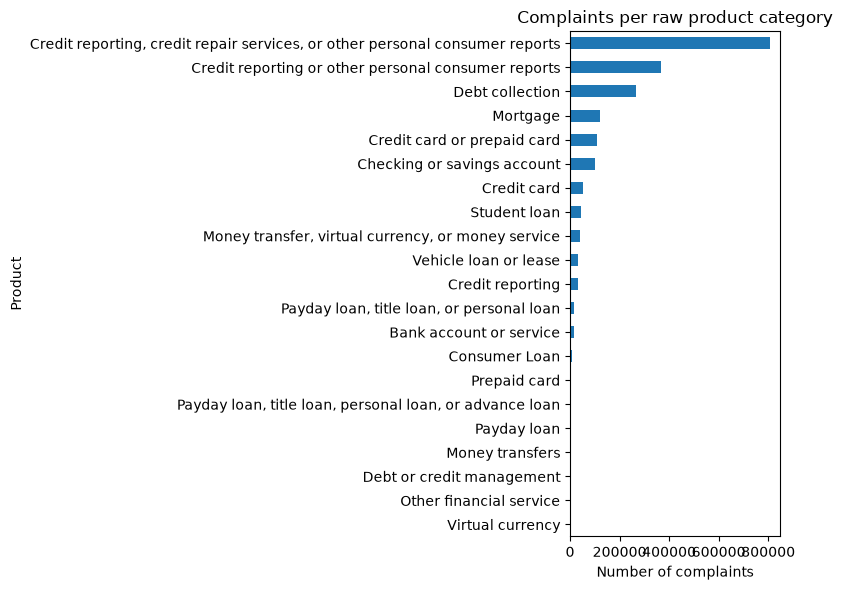

In [5]:
# Adjust the candidate list if your column name differs
product_candidates = ['Product', 'product', 'Category', 'category']
product_col = next((c for c in product_candidates if c in df.columns), None)
assert product_col, f"None of {product_candidates} found - check df.columns above and set product_col manually"
print(f"Using column: '{product_col}'")

class_counts = df[product_col].value_counts()
print(f"\nNumber of raw classes: {class_counts.shape[0]}")
print(f"\n{class_counts}")

class_counts.plot(kind='barh', figsize=(8, 6))
plt.xlabel('Number of complaints')
plt.title('Complaints per raw product category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 4. Narrative field - coverage and missingness

In CFPB's full public release only complaints where the consumer opted in carry free text. This Kaggle extract is already pre-filtered to those rows — the check below confirms it (100% coverage, so the filter is a no-op kept as a guard rather than a real reduction).

In [6]:
narrative_candidates = ['Consumer complaint narrative', 'Consumer_complaint_narrative', 'narrative', 'complaint_narrative']
narrative_col = next((c for c in narrative_candidates if c in df.columns), None)
assert narrative_col, f"None of {narrative_candidates} found - check df.columns above and set narrative_col manually"
print(f"Using column: '{narrative_col}'")

total_rows = len(df)
narrative_present = df[narrative_col].notna().sum()
print(f"Total rows: {total_rows}")
print(f"Rows with narrative text: {narrative_present} ({narrative_present/total_rows:.1%})")

df_narrative = df[df[narrative_col].notna()].copy()
print(f"\nAfter filtering to narrative rows: {df_narrative.shape[0]} rows, "
      f"{df_narrative[product_col].nunique()} raw classes")


Using column: 'narrative'
Total rows: 2023066
Rows with narrative text: 2023066 (100.0%)

After filtering to narrative rows: 2023066 rows, 21 raw classes


## 5. Duplicates and missing values

In [7]:
print("Duplicate rows:", df_narrative.duplicated().sum())
print("\nMissing values per column (top 10):")
print(df_narrative.isnull().sum().sort_values(ascending=False).head(10))


Duplicate rows: 0

Missing values per column (top 10):
Sub-issue        230559
Sub-product       52206
State              7344
narrative             0
product_5             0
Unnamed: 0            0
Product               0
Issue                 0
Date received         0
Company               0
dtype: int64


## 6. Narrative length statistics

count    2.023066e+06
mean     1.814544e+02
std      2.325449e+02
min      1.000000e+00
25%      6.200000e+01
50%      1.190000e+02
75%      2.150000e+02
max      6.314000e+03
Name: narrative_word_count, dtype: float64


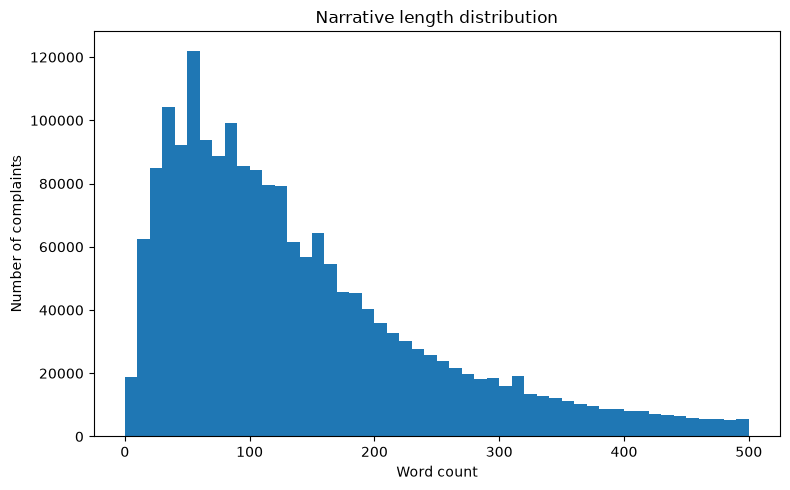

In [8]:
df_narrative['narrative_word_count'] = df_narrative[narrative_col].str.split().str.len()

print(df_narrative['narrative_word_count'].describe())

plt.figure(figsize=(8, 5))
plt.hist(df_narrative['narrative_word_count'], bins=50, range=(0, 500))
plt.xlabel('Word count')
plt.ylabel('Number of complaints')
plt.title('Narrative length distribution')
plt.tight_layout()
plt.show()


## 7. Consolidating product categories into 9 classes

The raw `Product` column has 21 values, but several are the same real category under different CFPB label vintages — the taxonomy has been relabeled more than once as complaint volume shifted (credit-reporting complaints alone made up over 80% of CFPB's total in FY2023, which is why that field in particular has been renamed repeatedly). The mapping below collapses those vintages into 9 classes.

**Note on this mapping, for the preprocessing writeup:** most merges follow CFPB's documented relabeling (the three credit-reporting variants, the combined "Credit card or prepaid card" label, etc.). The one lower-confidence merge is `Consumer Loan` -> `Vehicle / consumer loan`, since `Consumer Loan` was an older umbrella label without a fully documented successor mapping — worth a caveat in the report rather than stating it as certain. The two smallest raw values (`Debt or credit management`, `Other financial service`, together 0.06% of rows) don't map cleanly to any of the 9 classes and are dropped rather than forced into a mismatched bucket.

Dropped 1196 rows with no clean category mapping
Remaining: 2021870 rows, 9 classes

product_9
Credit reporting                     1205275
Debt collection                       266842
Credit card / prepaid card            163710
Mortgage                              119116
Bank account or service               115332
Student loan                           44241
Money transfer / virtual currency      43016
Vehicle / consumer loan                41538
Payday / title / personal loan         22800
Name: count, dtype: int64


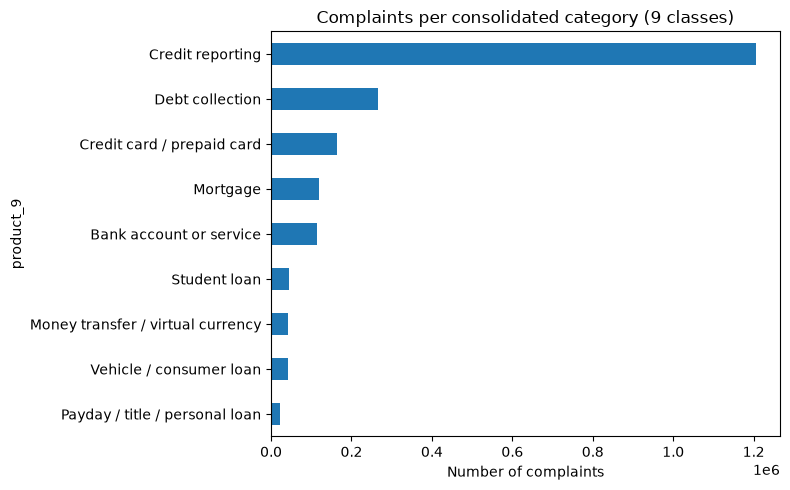

In [9]:
category_map = {
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
    "Credit reporting or other personal consumer reports": "Credit reporting",
    "Credit reporting": "Credit reporting",
    "Debt collection": "Debt collection",
    "Credit card or prepaid card": "Credit card / prepaid card",
    "Credit card": "Credit card / prepaid card",
    "Prepaid card": "Credit card / prepaid card",
    "Mortgage": "Mortgage",
    "Checking or savings account": "Bank account or service",
    "Bank account or service": "Bank account or service",
    "Student loan": "Student loan",
    "Money transfer, virtual currency, or money service": "Money transfer / virtual currency",
    "Money transfers": "Money transfer / virtual currency",
    "Virtual currency": "Money transfer / virtual currency",
    "Vehicle loan or lease": "Vehicle / consumer loan",
    "Consumer Loan": "Vehicle / consumer loan",
    "Payday loan, title loan, or personal loan": "Payday / title / personal loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday / title / personal loan",
    "Payday loan": "Payday / title / personal loan",
    "Debt or credit management": None,   # dropped - doesn't map cleanly to any of the 9 classes
    "Other financial service": None,     # dropped - doesn't map cleanly to any of the 9 classes
}

df_narrative['product_9'] = df_narrative[product_col].map(category_map)

# Drop the tiny leftover that doesn't map to a coherent class (~0.06% of rows)
n_before = len(df_narrative)
df_narrative = df_narrative[df_narrative['product_9'].notna()].copy()
print(f"Dropped {n_before - len(df_narrative)} rows with no clean category mapping")
print(f"Remaining: {len(df_narrative)} rows, {df_narrative['product_9'].nunique()} classes")

class_counts_9 = df_narrative['product_9'].value_counts()
print(f"\n{class_counts_9}")

class_counts_9.plot(kind='barh', figsize=(8, 5))
plt.xlabel('Number of complaints')
plt.title('Complaints per consolidated category (9 classes)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Narrowing to the modelling frame and memory management

To manage memory efficiently while preserving optionality for downstream modeling and error analysis, we isolate the required modeling columns into `df_model` and free the full raw dataframe:
- **Target label**: `product_9` (9-class consolidated label scheme).
- **Text input**: `narrative` (consumer complaint narrative text).
- **Granular metadata**: `Sub-product`, `Issue`, `Sub-issue` (retained for error analysis and potential novelty extension).
- **Reference column**: `product_5` (uploader's 5-class consolidation kept strictly for reporting comparison).
- **Dropped**: `Unnamed: 0`, `Date received`, `Company`, `State`, `Timely response?`.

In [10]:
# Measure deep memory usage of the full narrative dataframe by column
print("Full frame memory usage (deep), by column:")
mem_full = df_narrative.memory_usage(deep=True)
print(mem_full.sort_values(ascending=False))
print(f"\nTotal: {mem_full.sum() / 1024**2:.1f} MB")


Full frame memory usage (deep), by column:
narrative               2074014664
Product                  112888821
Issue                     97270973
Sub-issue                 88379439
Company                   69806257
Sub-product               52034847
product_9                 51166542
product_5                 48244447
Date received             36646394
Timely response?          22467120
State                     20464946
Unnamed: 0                16174960
Index                     16174960
narrative_word_count      16174960
dtype: int64

Total: 2595.8 MB


In [11]:
# Extract required modeling columns and garbage collect raw frames
model_cols = ['product_9', narrative_col, 'Sub-product', 'Issue', 'Sub-issue', 'product_5']
df_model = df_narrative[model_cols].copy()

del df, df_narrative
gc.collect()

print(f"df_model shape: {df_model.shape}")
print(f"df_model memory usage: {df_model.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
df_model.head()


df_model shape: (2021870, 6)
df_model memory usage: 2314.8 MB


## 9. Text Preprocessing Pipeline (3.4)

The raw complaint narratives contain noise, personally identifiable information (PII) redaction artifacts, variable casing, punctuation, and extraneous symbols. To prepare the text for representation learning and classification, we establish two distinct preprocessing pipelines grounded in the structural requirements of classical vs. contextual NLP architectures.

### 9.1 Justification of Preprocessing Decisions

1. **CFPB PII Redaction Mask Removal (`XXXX`, dates, amounts)**:
   CFPB scrubs confidential consumer and institutional data prior to public release, replacing names, account numbers, dates, and amounts with uppercase `X` strings (e.g., `XXXX`, `XX/XX/XXXX`, `$XXXX.XX`, `XXXX-XXXX`). If left untreated, `XXXX` becomes the single most frequent token in the corpus across all classes, dominating top TF-IDF weights and distorting bag-of-words vocabularies with zero discriminative value. Stripping these synthetic artifacts ensures models focus exclusively on authentic complaint vocabulary.

2. **URL, Contact, and Noise Filtering**:
   Web links, email addresses, and orphaned special characters (`#`, `@`, `~`, `*`) represent communication metadata rather than narrative semantics and are removed via regular expressions.

3. **Contraction Expansion & Case Normalization**:
   Standardizing contractions (e.g., *didn't* $\to$ *did not*, *won't* $\to$ *will not*) and converting to lowercase for classical models unifies morphological variants into common root representations, reducing vocabulary sparsity.

4. **Dual Preprocessing Strategy (Classical vs. Contextual)**:
   - **Classical Pipeline (`narrative_classical`)**: Lowercasing, contraction expansion, PII stripping, punctuation removal, stopword filtering (via standard English stopwords), and pruning of short residual noise (<3 characters). This compact vocabulary maximizes feature density for TF-IDF, Naive Bayes, Logistic Regression, Random Forest, and static embeddings (Word2Vec/GloVe).
   - **Contextual Pipeline (`narrative_contextual`)**: PII redaction masks and noise are removed, while sentence casing, natural punctuation, and grammatical structure are strictly preserved. Pretrained transformer architectures (such as BERT Base) utilize positional encodings and subword tokenizers (WordPiece) that derive significant semantic meaning from capitalization (e.g., proper nouns, acronyms) and syntactic sentence boundaries.

5. **Language Verification**:
   While CFPB data is overwhelmingly English, a character-level ASCII proportion check confirms the language purity of the dataset before model training.

In [12]:
# Contraction expansion mapping for standardizing colloquial forms
CONTRACTIONS = {
    r"won't": "will not",
    r"can't": "cannot",
    r"n't": " not",
    r"'re": " are",
    r"'s": " is",
    r"'d": " would",
    r"'ll": " will",
    r"'t": " not",
    r"'ve": " have",
    r"'m": " am"
}

# Preprocessing function for contextual neural models (e.g. BERT Base)
# Preserves natural casing and syntactic punctuation while removing PII artifacts and URLs
def clean_contextual(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\b\S+@\S+\.\S+\b', ' ', text)
    text = re.sub(r'\$[\sXx\d,.]+', ' ', text)
    text = re.sub(r'\b[Xx\d]+(?:[-/_][Xx\d]+)+\b', ' ', text)
    text = re.sub(r'\b[Xx]{2,}\b', ' ', text)
    text = re.sub(r'(?:^|\s)[#@^&~*+\\=/|<>_]+(?=\s|$)', ' ', text)
    text = re.sub(r'\s+([,;.!?])', r'\1', text)
    text = re.sub(r'([,;.!?])(?:\s*[,;.!?])+', r'\1', text)
    text = re.sub(r'\b(on|in|at|by|from|dated|re)\s*[,;]', r'\1', text, flags=re.IGNORECASE)
    text = re.sub(r'^\s*[,;.!?]+\s*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Preprocessing function for classical ML and bag-of-words models (TF-IDF, Naive Bayes, LR, RF, Word2Vec)
# Applies full lowercasing, contraction expansion, punctuation removal, and stopword filtering
def clean_classical(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = clean_contextual(text).lower()
    for pattern, replacement in CONTRACTIONS.items():
        text = re.sub(pattern, replacement, text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [w for w in text.split() if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)


print("Preprocessing pipelines defined.")
print(f"  Contraction patterns : {len(CONTRACTIONS)}")
print(f"  Stopwords filtered   : {len(ENGLISH_STOP_WORDS)}")
print("  narrative_contextual : casing, punctuation and sentence syntax preserved (BERT Base)")
print("  narrative_classical  : lowercased, punctuation-free, stopword-filtered (TF-IDF / Word2Vec)")


Preprocessing pipelines defined.
  Contraction patterns : 10
  Stopwords filtered   : 318
  narrative_contextual : casing, punctuation and sentence syntax preserved (BERT Base)
  narrative_classical  : lowercased, punctuation-free, stopword-filtered (TF-IDF / Word2Vec)


In [13]:
# Demonstrate preprocessing transformations on representative complaints across diverse categories
sample_indices = [0, 100, 500]
for idx in sample_indices:
    if idx < len(df_model):
        raw_sample = df_model.iloc[idx][narrative_col]
        category = df_model.iloc[idx]['product_9']
        print(f"=== Sample Index {idx} | Category: {category} ===")
        print(f"Raw Text (First 250 chars):\n  {raw_sample[:250]}...\n")
        print(f"Contextual (BERT-ready):\n  {clean_contextual(raw_sample)[:250]}...\n")
        print(f"Classical (TF-IDF-ready):\n  {clean_classical(raw_sample)[:250]}...\n")
        print("-" * 75)


=== Sample Index 0 | Category: Credit reporting ===
Raw Text (First 250 chars):
  Dear Possible Financial Inc you guyss aree reporting to the Credit bureaus that I have a charge off and Collection with you guys on XXXX and just a charge off on XXXX. None of these show on my XXXX Credit Report. I know this could be a minor mistake ...

Contextual (BERT-ready):
  Dear Possible Financial Inc you guyss aree reporting to the Credit bureaus that I have a charge off and Collection with you guys on and just a charge off on. None of these show on my Credit Report. I know this could be a minor mistake on you guys end...

Classical (TF-IDF-ready):
  dear possible financial guyss aree reporting credit bureaus charge collection guys just charge credit report know minor mistake guys end guys complaints credit reporting unaware debt didnt didnt opportunity dispute information fact believe gave prope...

---------------------------------------------------------------------------
=== Sample Index 100 |

In [14]:
# Apply contextual and classical preprocessing across the modelling dataset
print("Applying text preprocessing pipelines to df_model...")
df_model['narrative_contextual'] = df_model[narrative_col].apply(clean_contextual)
df_model['narrative_classical'] = df_model[narrative_col].apply(clean_classical)

# Filter out any rare complaints that became empty after cleaning
empty_mask = (df_model['narrative_classical'].str.strip() == "")
if empty_mask.sum() > 0:
    print(f"Dropping {empty_mask.sum()} empty narrative entries after cleaning...")
    df_model = df_model[~empty_mask].copy()

# Language verification: Check non-ASCII character proportion
def ascii_ratio(text: str) -> float:
    if not text:
        return 1.0
    return sum(1 for c in text if ord(c) < 128) / len(text)

non_english_sample = (df_model['narrative_contextual'].apply(ascii_ratio) < 0.8).sum()
print(f"Total modeling records: {len(df_model):,}")
print(f"Non-English / High non-ASCII records (<80% ASCII): {non_english_sample:,} ({non_english_sample / len(df_model):.3%})")
df_model[['product_9', 'narrative_contextual', 'narrative_classical']].head()


Applying text preprocessing pipelines to df_model...
Dropping 450 empty narrative entries after cleaning...
Total modeling records: 2,021,420
Non-English / High non-ASCII records (<80% ASCII): 0 (0.000%)


Raw Narrative Word Count Summary:
count    2.021420e+06
mean     1.814811e+02
std      2.325751e+02
min      1.000000e+00
25%      6.200000e+01
50%      1.190000e+02
75%      2.150000e+02
max      6.314000e+03
Name: raw_word_count, dtype: float64

Cleaned (Classical) Word Count Summary:
count    2.021420e+06
mean     6.997942e+01
std      9.399315e+01
min      1.000000e+00
25%      2.300000e+01
50%      4.400000e+01
75%      8.100000e+01
max      3.265000e+03
Name: classical_word_count, dtype: float64
df_model Memory Footprint with Preprocessed Features: 5218.6 MB


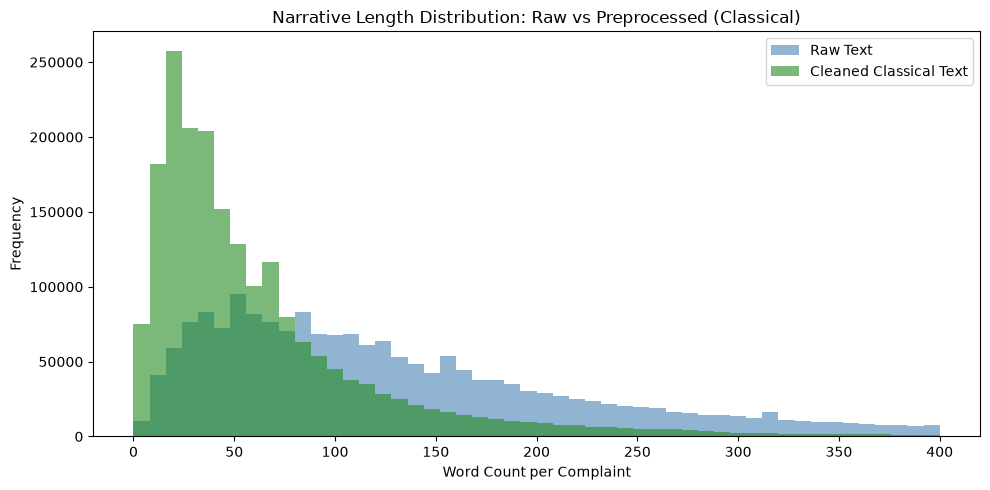

In [15]:
# Compute word length distributions before vs after classical preprocessing
df_model['raw_word_count'] = df_model[narrative_col].str.split().str.len()
df_model['classical_word_count'] = df_model['narrative_classical'].str.split().str.len()

print("Raw Narrative Word Count Summary:")
print(df_model['raw_word_count'].describe())
print("\nCleaned (Classical) Word Count Summary:")
print(df_model['classical_word_count'].describe())

# Plot comparative narrative length distribution
plt.figure(figsize=(10, 5))
plt.hist(df_model['raw_word_count'], bins=50, range=(0, 400), alpha=0.6, label='Raw Text', color='steelblue')
plt.hist(df_model['classical_word_count'], bins=50, range=(0, 400), alpha=0.6, label='Cleaned Classical Text', color='forestgreen')
plt.xlabel('Word Count per Complaint')
plt.ylabel('Frequency')
plt.title('Narrative Length Distribution: Raw vs Preprocessed (Classical)')
plt.legend()
plt.tight_layout()
plt.show()

# Memory usage of the preprocessed modelling frame
mem_preprocessed = df_model.memory_usage(deep=True).sum() / 1024**2
print(f"df_model Memory Footprint with Preprocessed Features: {mem_preprocessed:.1f} MB")


### 9.1 Per-Class Vocabulary — Word Clouds

Length statistics describe *how much* text each class carries; the word clouds
below show *which* terms carry it. They are generated from the cleaned
`narrative_classical` field, so stopwords and the `XXXX` PII redaction markers
are already removed and the surviving terms are the ones the classical models
actually see as TF-IDF features.

These directly motivate the error analysis in Section 13.2: classes whose
clouds share vocabulary are the classes the models later confuse.


Top 8 terms per class (by frequency in the cleaned narratives):
  Bank account or service                account, bank, money, told, check, funds, did, called
  Credit card / prepaid card             card, credit, account, payment, bank, did, received, told
  Credit reporting                       credit, report, information, consumer, account, reporting, accounts, payment
  Debt collection                        debt, credit, report, account, information, consumer, collection, accounts
  Money transfer / virtual currency      account, bank, money, funds, did, told, paypal, sent
  Mortgage                               mortgage, loan, payment, account, payments, home, received, did
  Payday / title / personal loan         loan, credit, account, payment, payments, company, pay, told
  Student loan                           loan, loans, payment, payments, mohela, account, student, time
  Vehicle / consumer loan                credit, car, payment, loan, vehicle, account, payments, told


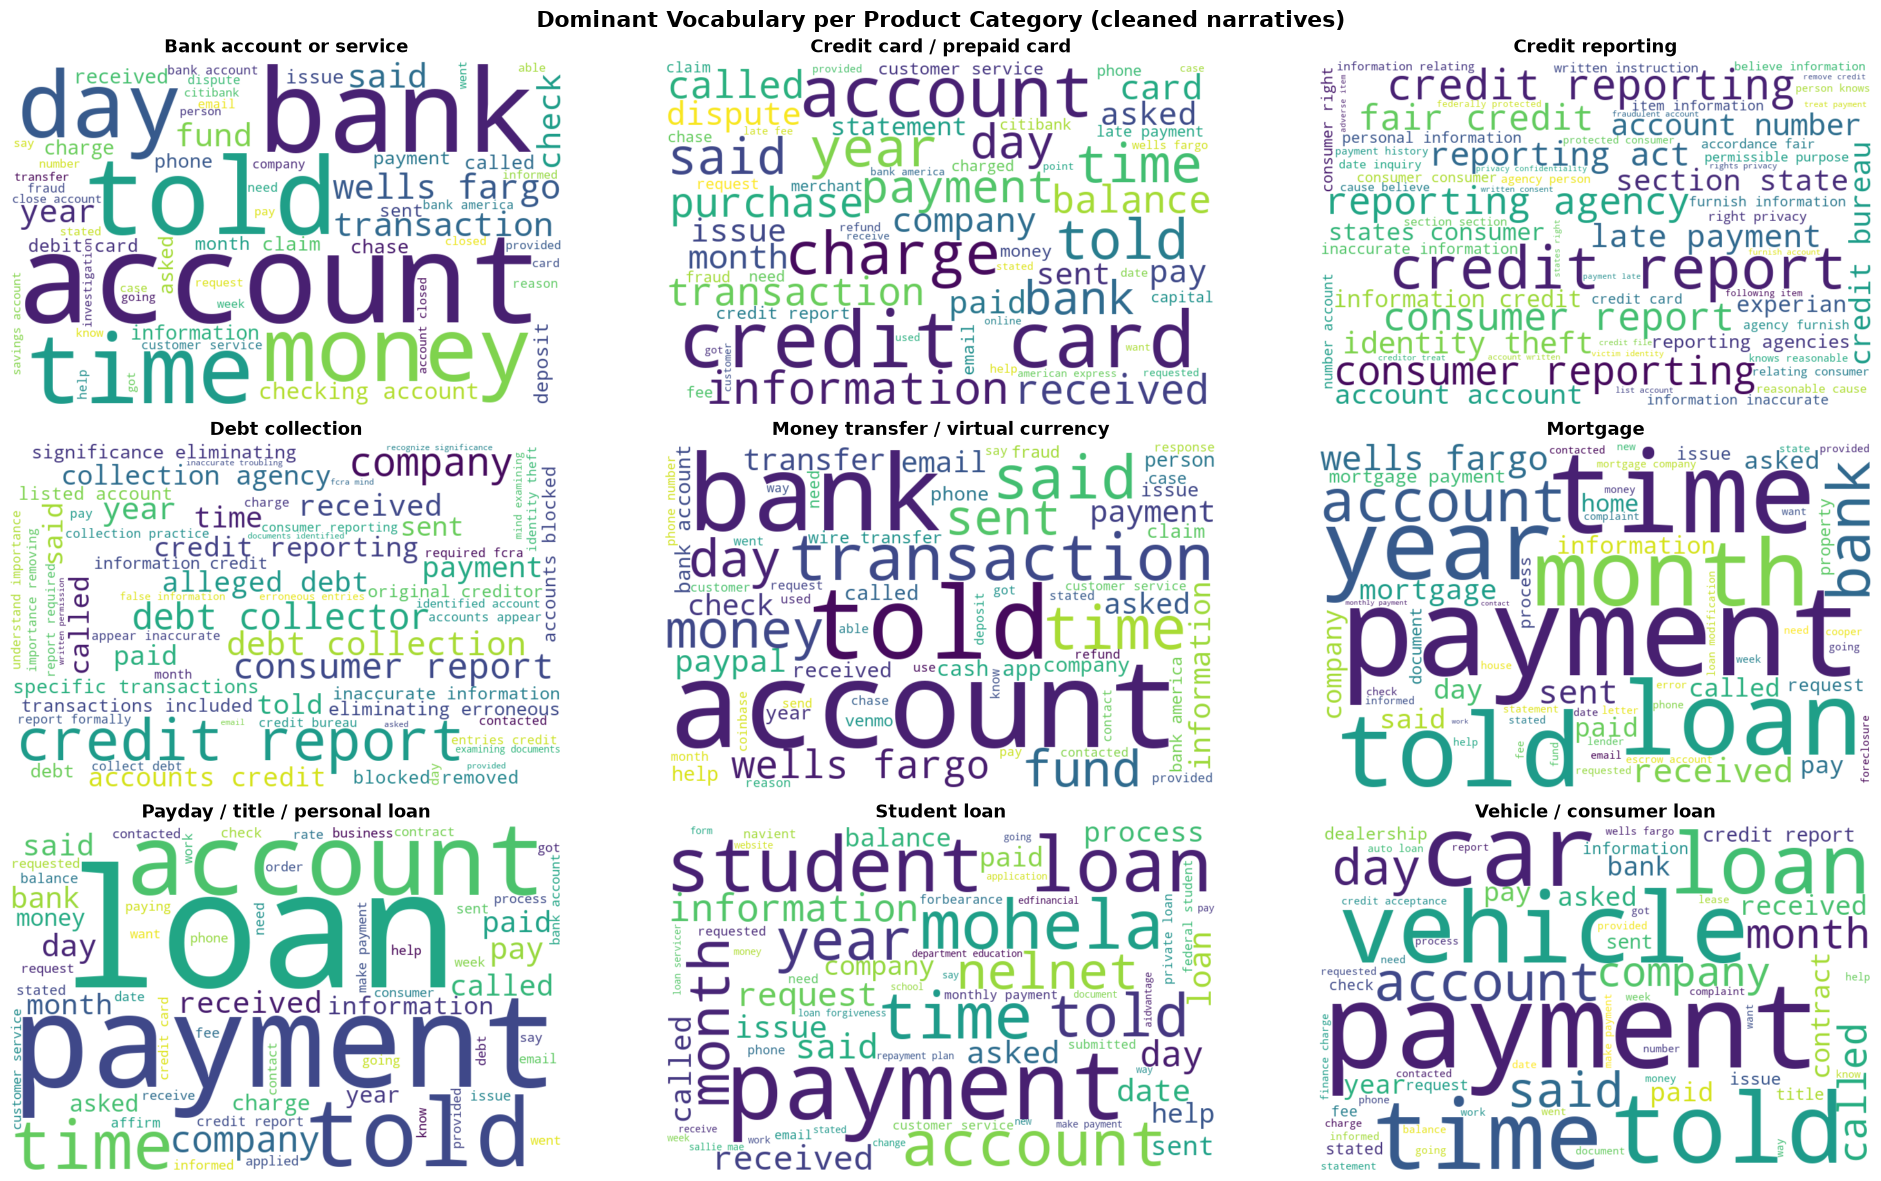

In [16]:
# Per-class word clouds over the cleaned narratives, to expose the vocabulary
# overlap that later drives the confusion-matrix corridors in Section 13.2
from collections import Counter

from wordcloud import WordCloud

wc_sample_per_class = 4000
fig, axes = plt.subplots(3, 3, figsize=(20, 12))

for ax, class_name in zip(axes.ravel(), sorted(df_model['product_9'].unique())):
    subset = df_model.loc[df_model['product_9'] == class_name, 'narrative_classical']
    subset = subset.head(wc_sample_per_class)
    text = ' '.join(subset.astype(str))

    cloud = WordCloud(width=800, height=500, background_color='white',
                      colormap='viridis', max_words=60, random_state=42).generate(text)
    ax.imshow(cloud, interpolation='bilinear')
    ax.set_title(class_name, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Dominant Vocabulary per Product Category (cleaned narratives)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify the overlap the clouds suggest, using the top terms of each class
print("Top 8 terms per class (by frequency in the cleaned narratives):")
for class_name in sorted(df_model['product_9'].unique()):
    subset = df_model.loc[df_model['product_9'] == class_name, 'narrative_classical'].head(wc_sample_per_class)
    counts = Counter(' '.join(subset.astype(str)).split())
    top = ', '.join(w for w, _ in counts.most_common(8))
    print(f"  {class_name:38s} {top}")


## 10. Stratified Dataset Splitting (3.5)

To prepare for representation learning (3.6) and model evaluation (3.7–3.9), we partition `df_model` into **Training (70%)**, **Validation (15%)**, and **Test (15%)** subsets using stratified sampling.

### 10.1 Justification of Splitting Strategy & Leakage Prevention

1. **Stratification across 9 Imbalanced Classes**:
   The CFPB dataset exhibits significant class imbalance (e.g., *Credit reporting* at ~59.6% vs. *Payday / personal loan* at ~1.1%). An unstratified random split risks statistical skew and variance in minority class representation across partitions. By stratifying strictly on `product_9`, we guarantee identical prior class distributions $P(Y=k)$ across Train, Validation, and Test sets.

2. **Partition Proportions (70 / 15 / 15)**:
   - **Train (70%, ~1.41M samples)**: Provides large sample volume necessary for fine-tuning deep neural architectures (SimpleRNN, GRU, LSTM, Bi-RNNs, BERT Base) and classical ML models without overfitting.
   - **Validation (15%, ~303k samples)**: Serves as an independent tuning split for early stopping, learning rate scheduling, and hyperparameter sweeps across $\ge 3$ configurations per model.
   - **Test (15%, ~303k samples)**: Held out strictly for final evaluation metrics (Accuracy, Macro/Weighted F1, Confusion Matrix, Classification Report).

3. **Strict Data Leakage Prevention Boundary**:
   All downstream feature extraction (TF-IDF vocabulary fitting, tokenizers, Word2Vec/GloVe vocabulary construction, and numerical scaling) must be fit exclusively on `train_df`. The validation and test sets are transformed strictly using parameters learned from the training set.

4. **Contiguous Target Label Encoding**:
   The 9 consolidated text categories are mapped to contiguous zero-indexed integers ($0 \dots 8$) using `LabelEncoder`. The explicit bidirectional mappings (`label2id` and `id2label`) are saved for decoding confusion matrices and classification reports.

In [17]:
# Stage 1: Partition into 70% Training set and 30% Temporary set (stratified by product_9)
train_df, temp_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=42,
    stratify=df_model['product_9']
)

# Stage 2: Partition Temporary set equally into 15% Validation and 15% Test sets (stratified by product_9)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['product_9']
)

# Free temporary split frame to reclaim memory
del temp_df
gc.collect()

# Report sample counts and percentage allocations
total_records = len(df_model)
print(f"Total Dataset Records: {total_records:,}")
print(f"Training Set:   {len(train_df):,} records ({len(train_df)/total_records:.1%})")
print(f"Validation Set: {len(val_df):,} records ({len(val_df)/total_records:.1%})")
print(f"Test Set:       {len(test_df):,} records ({len(test_df)/total_records:.1%})")


Total Dataset Records: 2,021,420
Training Set:   1,414,994 records (70.0%)
Validation Set: 303,213 records (15.0%)
Test Set:       303,213 records (15.0%)


In [18]:
# Initialize LabelEncoder and fit on the closed set of 9 product classes
label_encoder = LabelEncoder()
label_encoder.fit(train_df['product_9'])

# Generate integer target arrays for each partition
y_train = label_encoder.transform(train_df['product_9'])
y_val = label_encoder.transform(val_df['product_9'])
y_test = label_encoder.transform(test_df['product_9'])

# Store target arrays in dataframe columns for downstream convenience
train_df['label_id'] = y_train
val_df['label_id'] = y_val
test_df['label_id'] = y_test

# Extract bidirectional class mapping dictionaries
id2label = {idx: label for idx, label in enumerate(label_encoder.classes_)}
label2id = {label: idx for idx, label in enumerate(label_encoder.classes_)}

print("Class Label to Integer ID Mapping:")
for label, idx in sorted(label2id.items(), key=lambda x: x[1]):
    print(f"  ID {idx}: {label}")


Class Label to Integer ID Mapping:
  ID 0: Bank account or service
  ID 1: Credit card / prepaid card
  ID 2: Credit reporting
  ID 3: Debt collection
  ID 4: Money transfer / virtual currency
  ID 5: Mortgage
  ID 6: Payday / title / personal loan
  ID 7: Student loan
  ID 8: Vehicle / consumer loan


Stratified Class Distribution Summary:
                                   Train Count  Train %  Val Count  Val %  \
product_9                                                                   
Credit reporting                        843398    59.60     180728  59.60   
Debt collection                         186773    13.20      40022  13.20   
Credit card / prepaid card              114596     8.10      24557   8.10   
Mortgage                                 83380     5.89      17867   5.89   
Bank account or service                  80731     5.71      17300   5.71   
Student loan                             30969     2.19       6636   2.19   
Money transfer / virtual currency        30111     2.13       6452   2.13   
Vehicle / consumer loan                  29076     2.05       6231   2.05   
Payday / title / personal loan           15960     1.13       3420   1.13   

                                   Test Count  Test %  
product_9                                              
C

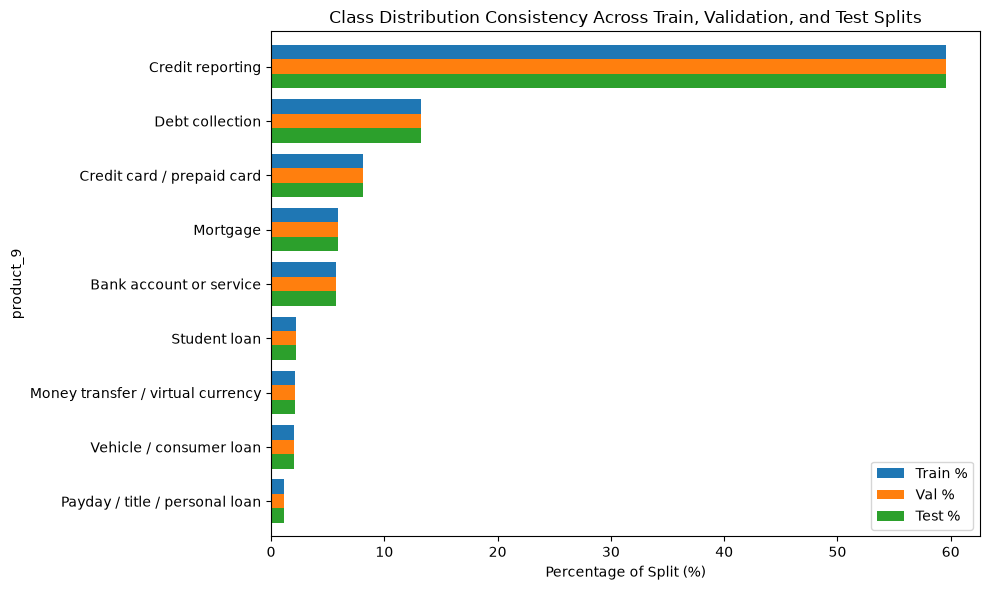

In [19]:
# Compute class distributions across all three splits to empirically verify stratification
dist_train = train_df['product_9'].value_counts(normalize=True).rename('Train %') * 100
dist_val = val_df['product_9'].value_counts(normalize=True).rename('Val %') * 100
dist_test = test_df['product_9'].value_counts(normalize=True).rename('Test %') * 100

counts_train = train_df['product_9'].value_counts().rename('Train Count')
counts_val = val_df['product_9'].value_counts().rename('Val Count')
counts_test = test_df['product_9'].value_counts().rename('Test Count')

stratification_df = pd.concat([counts_train, dist_train, counts_val, dist_val, counts_test, dist_test], axis=1)
print("Stratified Class Distribution Summary:")
print(stratification_df.round(2))

# Plot comparative class proportions across splits
fig, ax = plt.subplots(figsize=(10, 6))
strat_percentages = pd.concat([dist_train, dist_val, dist_test], axis=1)
strat_percentages.plot(kind='barh', ax=ax, width=0.8)
ax.set_xlabel('Percentage of Split (%)')
ax.set_title('Class Distribution Consistency Across Train, Validation, and Test Splits')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 11. Text Representations (3.6)

To evaluate classical machine learning, recurrent neural networks, and transformer architectures in Section 3.7, we construct multiple feature representations strictly fitted on `train_df` (zero data leakage).

### 11.1 Justification of Representation Strategies

1. **TF-IDF Sparse Representation (`TfidfVectorizer`)**:
   - **Configuration**: Unigram + Bigram features ($n \in \{1, 2\}$), sublinear term frequency scaling ($1 + \log(\text{tf})$), vocabulary capped at top 25,000 terms (`min_df=5`, `max_df=0.85`).
   - **Justification**: TF-IDF weights discriminative terms inversely to their document frequency. Sublinear scaling mitigates the distortion caused by word repetition in lengthy complaints. Bigrams capture essential multi-word financial concepts (e.g., *"late fee"*, *"credit score"*, *"escrow balance"*). This representation provides high feature density for linear and tree-based models (**Logistic Regression, Naive Bayes, Random Forest**).

2. **Continuous Bag-of-Words (CBOW) Word Embeddings (`Word2Vec`)**:
   - **Configuration**: 100-dimensional dense vectors trained via Continuous Bag-of-Words (`vector_size=100`, `window=5`, `min_count=5`, `epochs=5`).
   - **Justification**: Generic pre-trained embeddings often lack specialized financial regulatory vocabulary. Training Word2Vec directly on CFPB complaints captures domain-specific semantic geometries (e.g., associations between *"charge-off"*, *"delinquent"*, and *"collection"*).

3. **Padded Sequence Indexing & Pretrained Neural Embedding Matrix (PyTorch)**:
   - **Configuration**: Integer sequence tensors truncated/padded to `max_len=256` using a fixed vocabulary of top 30,000 terms, initialized with the domain Word2Vec weight matrix.
   - **Justification**: Uniform sequence tensors enable GPU-accelerated batching for recurrent neural networks (**SimpleRNN, GRU, LSTM, and Bidirectional variants**).

4. **Strict Zero-Leakage Boundary**:
   All vectorizers, tokenizers, and vocabularies are learned exclusively on `train_df`. Validation and test sets are transformed without modifying vocabulary indices or IDF weights.

In [20]:
# Initialize TF-IDF Vectorizer with sublinear term scaling and unigram + bigram features
tfidf_vectorizer = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5,
    max_df=0.85
)

# Fit exclusively on training narratives and transform validation and test sets
print("Fitting TF-IDF vectorizer on training narratives...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['narrative_classical'])
X_val_tfidf = tfidf_vectorizer.transform(val_df['narrative_classical'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['narrative_classical'])

print(f"TF-IDF Feature Space: {len(tfidf_vectorizer.vocabulary_):,} terms")
print(f"X_train_tfidf Shape: {X_train_tfidf.shape} | Non-zero elements: {X_train_tfidf.nnz:,}")
print(f"X_val_tfidf Shape:   {X_val_tfidf.shape}")
print(f"X_test_tfidf Shape:  {X_test_tfidf.shape}")

# Display top 20 global TF-IDF features by mean weight
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top_feature_indices = mean_tfidf.argsort()[::-1][:20]
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

top_tfidf_df = pd.DataFrame({
    'Feature (Unigram/Bigram)': feature_names[top_feature_indices],
    'Mean TF-IDF Weight': mean_tfidf[top_feature_indices]
})
print("\nTop 20 Salient TF-IDF Features in Training Corpus:")
print(top_tfidf_df.to_string(index=False))


Fitting TF-IDF vectorizer on training narratives...
TF-IDF Feature Space: 25,000 terms
X_train_tfidf Shape: (1414994, 25000) | Non-zero elements: 103,726,073
X_val_tfidf Shape:   (303213, 25000)
X_test_tfidf Shape:  (303213, 25000)

Top 20 Salient TF-IDF Features in Training Corpus:
Feature (Unigram/Bigram)  Mean TF-IDF Weight
                  credit            0.035087
                 account            0.029733
                  report            0.028519
             information            0.023352
               reporting            0.023010
           credit report            0.021504
                accounts            0.018748
                consumer            0.018587
                 section            0.015892
                     did            0.014160
                    debt            0.013834
                 company            0.013764
                 payment            0.013528
                  states            0.013101
                  agency            0.012

In [21]:
# Tokenize classical training narratives for word embedding learning
print("Tokenizing training corpus for Word2Vec...")
tokenized_train = [text.split() for text in train_df['narrative_classical']]

# Train Continuous Bag-of-Words (CBOW) Word2Vec model on domain narratives
print("Training Word2Vec model (vector_size=100, window=5, min_count=5)...")
w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=5,
    seed=42
)

print(f"Word2Vec Trained Vocabulary Size: {len(w2v_model.wv):,} words")

# Verify semantic coherence on key financial anchor terms
anchor_terms = ['mortgage', 'dispute', 'debt', 'overdraft', 'bureau']
print("\nWord2Vec Semantic Similarity Inspection (Top 3 Nearest Neighbors):")
for term in anchor_terms:
    if term in w2v_model.wv:
        neighbors = w2v_model.wv.most_similar(term, topn=3)
        formatted_neighbors = ", ".join([f"{word} ({sim:.3f})" for word, sim in neighbors])
        print(f"  '{term}' -> {formatted_neighbors}")


Tokenizing training corpus for Word2Vec...
Training Word2Vec model (vector_size=100, window=5, min_count=5)...
Word2Vec Trained Vocabulary Size: 47,051 words

Word2Vec Semantic Similarity Inspection (Top 3 Nearest Neighbors):
  'mortgage' -> mortage (0.872), morgage (0.815), mortgae (0.750)
  'dispute' -> disputes (0.727), disput (0.671), depute (0.576)
  'debt' -> debts (0.751), deb (0.745), erc (0.640)
  'overdraft' -> nsf (0.809), overdrafts (0.808), overdrawn (0.767)
  'bureau' -> bureaus (0.745), burea (0.661), agencies (0.637)


In [22]:
# Build vocabulary from training tokens (capped at top 30,000 terms)
word_counts = Counter()
for tokens in tokenized_train:
    word_counts.update(tokens)

vocab = {"<PAD>": 0, "<UNK>": 1}
max_vocab_size = 30000
for word, _ in word_counts.most_common(max_vocab_size - 2):
    vocab[word] = len(vocab)

print(f"Neural Vocabulary Size: {len(vocab):,} tokens (including <PAD> and <UNK>)")

# Vectorized sequence encoding function
def encode_sequences(texts, vocab_dict, max_length=256):
    encoded = np.zeros((len(texts), max_length), dtype=np.int64)
    unk_id = vocab_dict["<UNK>"]
    for i, text in enumerate(texts):
        tokens = text.split()[:max_length]
        for j, token in enumerate(tokens):
            encoded[i, j] = vocab_dict.get(token, unk_id)
    return encoded

print("Encoding training, validation, and test sequences (max_len=256)...")
X_train_seq = encode_sequences(train_df['narrative_classical'].values, vocab, max_length=256)
X_val_seq = encode_sequences(val_df['narrative_classical'].values, vocab, max_length=256)
X_test_seq = encode_sequences(test_df['narrative_classical'].values, vocab, max_length=256)

print(f"X_train_seq Tensor Shape: {X_train_seq.shape}")
print(f"X_val_seq Tensor Shape:   {X_val_seq.shape}")
print(f"X_test_seq Tensor Shape:  {X_test_seq.shape}")

# Initialize pretrained embedding weight matrix from Word2Vec
embedding_dim = 100
embedding_matrix = np.random.normal(scale=0.1, size=(len(vocab), embedding_dim))
embedding_matrix[0] = np.zeros(embedding_dim)

matched_count = 0
for word, idx in vocab.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        matched_count += 1

pretrained_embedding_weights = torch.tensor(embedding_matrix, dtype=torch.float32)
print(f"Pretrained Embedding Weights Tensor Shape: {pretrained_embedding_weights.shape}")
print(f"Vocabulary matched in Word2Vec: {matched_count:,} / {len(vocab):,} ({matched_count/len(vocab):.1%})")


Neural Vocabulary Size: 30,000 tokens (including <PAD> and <UNK>)
Encoding training, validation, and test sequences (max_len=256)...
X_train_seq Tensor Shape: (1414994, 256)
X_val_seq Tensor Shape:   (303213, 256)
X_test_seq Tensor Shape:  (303213, 256)
Pretrained Embedding Weights Tensor Shape: torch.Size([30000, 100])
Vocabulary matched in Word2Vec: 29,998 / 30,000 (100.0%)


In [23]:
# Summary comparison of extracted text representations
repr_summary = pd.DataFrame([
    {
        'Representation': 'TF-IDF (Sparse CSR)',
        'Input Pipeline': 'narrative_classical',
        'Dimensions': f"({X_train_tfidf.shape[0]:,}, {X_train_tfidf.shape[1]:,})",
        'Data Type': 'Sparse Float64',
        'Target Models': 'Logistic Regression, Naive Bayes, Random Forest'
    },
    {
        'Representation': 'Word2Vec (CBOW Embeddings)',
        'Input Pipeline': 'narrative_classical',
        'Dimensions': f"Vocab: {len(w2v_model.wv):,}, Dim: {w2v_model.vector_size}",
        'Data Type': 'Dense Float32',
        'Target Models': 'Semantic space / Initialized Weights'
    },
    {
        'Representation': 'Padded Sequences + Pretrained Weights',
        'Input Pipeline': 'narrative_classical',
        'Dimensions': f"({X_train_seq.shape[0]:,}, 256), Matrix: {list(pretrained_embedding_weights.shape)}",
        'Data Type': 'Int64 Tensor + Float32 Tensor',
        'Target Models': 'SimpleRNN, GRU, LSTM, Bi-RNNs'
    },
    {
        'Representation': 'BERT Tokenizer (Contextual Subwords)',
        'Input Pipeline': 'narrative_contextual',
        'Dimensions': 'Dynamic Subwords (WordPiece, max_len=256)',
        'Data Type': 'Input IDs + Attention Masks',
        'Target Models': 'BERT Base (HuggingFace)'
    }
])

print("Text Representations Architecture Matrix:")
print(repr_summary.to_string(index=False))


Text Representations Architecture Matrix:
                       Representation       Input Pipeline                                Dimensions                     Data Type                                   Target Models
                  TF-IDF (Sparse CSR)  narrative_classical                       (1,414,994, 25,000)                Sparse Float64 Logistic Regression, Naive Bayes, Random Forest
           Word2Vec (CBOW Embeddings)  narrative_classical                   Vocab: 47,051, Dim: 100                 Dense Float32            Semantic space / Initialized Weights
Padded Sequences + Pretrained Weights  narrative_classical    (1,414,994, 256), Matrix: [30000, 100] Int64 Tensor + Float32 Tensor                   SimpleRNN, GRU, LSTM, Bi-RNNs
 BERT Tokenizer (Contextual Subwords) narrative_contextual Dynamic Subwords (WordPiece, max_len=256)   Input IDs + Attention Masks                         BERT Base (HuggingFace)


## 12. Model Training & Hyperparameter Tuning (3.7 & 3.8)

In this section, we implement, train, and systematically tune all **10 required architectures** across 3 distinct modeling paradigms:
1. **Classical Machine Learning (3 models)**: Logistic Regression, Multinomial Naive Bayes, Random Forest (using TF-IDF sparse features).
2. **Recurrent Neural Networks (6 models)**: SimpleRNN, GRU, LSTM, Bidirectional SimpleRNN, Bidirectional GRU, Bidirectional LSTM (using sequence tensors + domain Word2Vec weights).
3. **Transformer Architecture (1 model)**: BERT Base (`bert-base-uncased` fine-tuned on contextual complaint text).

### 12.1 Justification of Modeling Decisions & Tuning Methodology

1. **Mitigating Extreme Class Imbalance**:
   Because *Credit reporting* comprises ~59.6% of complaints while *Payday loans* account for ~1.1%, standard cross-entropy / unweighted loss leads models to collapse toward majority-class predictions. We compute inverse frequency class weights:
   $$w_k = \frac{N}{K \cdot N_k}$$
   and incorporate them across both classical classifiers (`class_weight='balanced'`) and neural networks (`nn.CrossEntropyLoss(weight=class_weights)`).

2. **Unified Evaluation & Tuning Criterion**:
   Every architecture is tuned across $\ge 3$ distinct hyperparameter configurations against the independent **Validation Set**. While Accuracy is recorded, **Validation Macro F1** ($F_{1,\text{macro}} = \frac{1}{K}\sum F_{1,k}$) is prioritized as the primary selection metric to give equal weight to minority product categories.

3. **Logging Specification (3.8)**:
   Every experimental run ($10 \text{ models} \times \ge 3 \text{ configs} = \ge 30 \text{ runs}$) is logged in a unified DataFrame (`tuning_results_df`) recording model family, configuration parameters, Validation Accuracy, Macro F1, Weighted F1, and training latency.

### 12.1 Experimental Protocol — Fixed Training Budget

Comparing ten architectures is only meaningful if they are given the same
resources. Fine-tuning BERT Base over the full 1.41M-row training split is not
tractable on a single RTX 4070 Ti Super within this project's timeframe, so the
transformer sets the ceiling for the whole comparison.

**Decision.** Every one of the ten architectures is trained on the *same*
stratified 200,000-row subsample of the training split, and every architecture
is scored on the *full* 303,213-row test split.

**Justification.**

- Stratified sampling preserves the exact class prior documented in Section 7,
  so the 59.6% *Credit reporting* majority and the 1.1% *Payday loan* minority
  are represented in the same proportion as the full corpus.
- Holding the budget fixed is what makes the Section 3.9 master table an
  apples-to-apples ranking. Training the classical models on 1.41M rows while
  BERT saw 50k would confound architecture with training-set size, and any
  conclusion about "which model is best" would be unsupported.
- The representations themselves (TF-IDF vocabulary, Word2Vec embeddings) are
  still fit on the **full** training split, as described in Section 3.6. Only
  the classifier fitting budget is capped, and validation/test partitions
  remain transform-only, so the zero-leakage boundary from Section 3.5 holds.
- Section 3.9 additionally reports the classical models refit on the full
  1.41M rows as a scale reference, quantifying what the budget costs.


In [24]:
# Compute inverse frequency class weights to counteract the 59.6% class imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

print("Computed Class Weights (Balanced):")
for idx, weight in enumerate(class_weights_array):
    print(f"  Class {idx} ({id2label[idx]}): {weight:.4f}")

# Unified evaluation metric utility returning Accuracy, Macro F1, and Weighted F1
def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1}

# Global log container for all tuning runs (3.8 requirement)
tuning_runs = []

def log_tuning_run(model_name, category, config_id, params, metrics, elapsed_time):
    run_record = {
        'Model': model_name,
        'Category': category,
        'Config ID': config_id,
        'Hyperparameters': str(params),
        'Val Accuracy': round(metrics['accuracy'], 4),
        'Val Macro F1': round(metrics['macro_f1'], 4),
        'Val Weighted F1': round(metrics['weighted_f1'], 4),
        'Training Time (s)': round(elapsed_time, 2)
    }
    tuning_runs.append(run_record)
    print(f"[{model_name} - Config {config_id}] Val Acc: {run_record['Val Accuracy']:.4f} | "
          f"Val Macro F1: {run_record['Val Macro F1']:.4f} | Time: {run_record['Training Time (s)']}s")


Computed Class Weights (Balanced):
  Class 0 (Bank account or service): 1.9475
  Class 1 (Credit card / prepaid card): 1.3720
  Class 2 (Credit reporting): 0.1864
  Class 3 (Debt collection): 0.8418
  Class 4 (Money transfer / virtual currency): 5.2214
  Class 5 (Mortgage): 1.8856
  Class 6 (Payday / title / personal loan): 9.8510
  Class 7 (Student loan): 5.0767
  Class 8 (Vehicle / consumer loan): 5.4073


In [25]:
# 1. Logistic Regression Hyperparameter Tuning (Configs: C=0.1, C=1.0, C=5.0)
lr_configs = [
    {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 200, 'solver': 'lbfgs'},
    {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 200, 'solver': 'lbfgs'},
    {'C': 5.0, 'class_weight': 'balanced', 'max_iter': 200, 'solver': 'lbfgs'}
]

print("=== Training & Tuning Logistic Regression (3 Configs) ===")
for i, cfg in enumerate(lr_configs, 1):
    t0 = time.time()
    clf = LogisticRegression(**cfg, random_state=42)
    clf.fit(X_train_tfidf, y_train)
    val_preds = clf.predict(X_val_tfidf)
    elapsed = time.time() - t0
    log_tuning_run('Logistic Regression', 'Classical ML', f'LR-C{cfg["C"]}', cfg, evaluate_metrics(y_val, val_preds), elapsed)

# 2. Multinomial Naive Bayes Hyperparameter Tuning (Configs: alpha=0.01, alpha=0.1, alpha=1.0)
nb_configs = [
    {'alpha': 0.01},
    {'alpha': 0.1},
    {'alpha': 1.0}
]

print("\n=== Training & Tuning Multinomial Naive Bayes (3 Configs) ===")
for i, cfg in enumerate(nb_configs, 1):
    t0 = time.time()
    clf = MultinomialNB(**cfg)
    clf.fit(X_train_tfidf, y_train)
    val_preds = clf.predict(X_val_tfidf)
    elapsed = time.time() - t0
    log_tuning_run('Naive Bayes', 'Classical ML', f'NB-a{cfg["alpha"]}', cfg, evaluate_metrics(y_val, val_preds), elapsed)

# 3. Random Forest Hyperparameter Tuning (Configs: n=50/depth=20, n=50/depth=30, n=50/depth=50)
rf_configs = [
    {'n_estimators': 50, 'max_depth': 20, 'class_weight': 'balanced', 'max_samples': 100000, 'random_state': 42, 'n_jobs': -1},
    {'n_estimators': 50, 'max_depth': 30, 'class_weight': 'balanced', 'max_samples': 100000, 'random_state': 42, 'n_jobs': -1},
    {'n_estimators': 50, 'max_depth': 50, 'class_weight': 'balanced', 'max_samples': 100000, 'random_state': 42, 'n_jobs': -1}
]

print("\n=== Training & Tuning Random Forest (3 Configs) ===")
for i, cfg in enumerate(rf_configs, 1):
    t0 = time.time()
    clf = RandomForestClassifier(**cfg)
    clf.fit(X_train_tfidf, y_train)
    val_preds = clf.predict(X_val_tfidf)
    elapsed = time.time() - t0
    log_tuning_run('Random Forest', 'Classical ML', f'RF-n{cfg["n_estimators"]}-d{cfg["max_depth"]}', cfg, evaluate_metrics(y_val, val_preds), elapsed)


=== Training & Tuning Logistic Regression (3 Configs) ===
[Logistic Regression - Config LR-C0.1] Val Acc: 0.8354 | Val Macro F1: 0.7378 | Time: 181.18s
[Logistic Regression - Config LR-C1.0] Val Acc: 0.8408 | Val Macro F1: 0.7373 | Time: 260.0s
[Logistic Regression - Config LR-C5.0] Val Acc: 0.8375 | Val Macro F1: 0.7309 | Time: 292.71s

=== Training & Tuning Multinomial Naive Bayes (3 Configs) ===
[Naive Bayes - Config NB-a0.01] Val Acc: 0.8320 | Val Macro F1: 0.7285 | Time: 0.93s
[Naive Bayes - Config NB-a0.1] Val Acc: 0.8317 | Val Macro F1: 0.7275 | Time: 1.06s
[Naive Bayes - Config NB-a1.0] Val Acc: 0.8296 | Val Macro F1: 0.7157 | Time: 0.98s

=== Training & Tuning Random Forest (3 Configs) ===
[Random Forest - Config RF-n50-d20] Val Acc: 0.7832 | Val Macro F1: 0.6590 | Time: 49.8s
[Random Forest - Config RF-n50-d30] Val Acc: 0.7931 | Val Macro F1: 0.6741 | Time: 105.29s
[Random Forest - Config RF-n50-d50] Val Acc: 0.8040 | Val Macro F1: 0.6870 | Time: 275.35s


C:\Users\nabil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\nabil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the 

In [26]:
# Modular PyTorch Recurrent Classifier Supporting SimpleRNN, GRU, LSTM, and Bi-directional variants
class RecurrentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, cell_type='lstm',
                 num_layers=1, bidirectional=False, dropout=0.3, pretrained_weights=None):
        super().__init__()
        self.cell_type = cell_type.lower()
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_weights, freeze=False, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        cells = {'rnn': nn.RNN, 'gru': nn.GRU, 'lstm': nn.LSTM}
        if self.cell_type not in cells:
            raise ValueError(f"Unsupported cell_type: {cell_type}")
        self.rnn = cells[self.cell_type](
            embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional, dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * self.num_directions, num_classes)

    # Sequences are right-padded to 256, but the median cleaned narrative is only
    # 44 tokens. Reading hidden[-1] off the unpacked sequence would therefore return
    # a state produced by ~200 trailing <PAD> steps. pack_padded_sequence makes the
    # RNN stop at each sequence's true final token instead.
    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        if self.cell_type == 'lstm':
            _, (hidden, _) = self.rnn(packed)
        else:
            _, hidden = self.rnn(packed)

        if self.bidirectional:
            last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last_hidden = hidden[-1]

        return self.fc(self.dropout(last_hidden))


# Training loop retaining the best epoch's weights alongside its metrics, so the
# reported score and the returned predictions describe the same model
def train_eval_torch_model(model, train_loader, eval_loader, criterion, optimizer,
                           epochs, device, y_eval, label=""):
    model = model.to(device)
    best_metrics, best_preds = {'macro_f1': -1.0}, None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch_x, batch_len, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x, batch_len), batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        preds = predict_torch_model(model, eval_loader, device)
        metrics = evaluate_metrics(y_eval, preds)
        print(f"    {label} epoch {epoch}/{epochs} loss={running_loss/len(train_loader):.4f} "
              f"macro_f1={metrics['macro_f1']:.4f} acc={metrics['accuracy']:.4f}")
        if metrics['macro_f1'] > best_metrics['macro_f1']:
            best_metrics, best_preds = metrics, preds

    return best_metrics, best_preds


# Batched inference helper shared by tuning and final evaluation
@torch.no_grad()
def predict_torch_model(model, loader, device):
    model.eval()
    all_preds = []
    for batch_x, batch_len, _ in loader:
        logits = model(batch_x.to(device), batch_len)
        all_preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(all_preds)


print("RecurrentClassifier and training utilities defined.")
print(f"  Supported cell types : {['rnn', 'gru', 'lstm']}")
print(f"  Padding handling     : pack_padded_sequence (true final hidden state)")


RecurrentClassifier and training utilities defined.
  Supported cell types : ['rnn', 'gru', 'lstm']
  Padding handling     : pack_padded_sequence (true final hidden state)


In [27]:
# Construct PyTorch DataLoaders over the fixed 200,000-row training budget
# Sequence lengths travel with the ids so the model can mask padding
train_dataset = TensorDataset(
    torch.tensor(X_train_seq, dtype=torch.long),
    torch.tensor(train_lengths, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val_seq, dtype=torch.long),
    torch.tensor(val_lengths, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# The 6 Recurrent Neural Network Architectures
rnn_models_to_tune = [
    ('SimpleRNN', 'rnn', False),
    ('GRU', 'gru', False),
    ('LSTM', 'lstm', False),
    ('Bidirectional SimpleRNN', 'rnn', True),
    ('Bidirectional GRU', 'gru', True),
    ('Bidirectional LSTM', 'lstm', True),
]

# 3 Distinct Hyperparameter Tuning Configurations per Recurrent Model
rnn_tuning_configs = [
    {'hidden_dim': 64, 'lr': 1e-3, 'dropout': 0.3, 'epochs': 4},
    {'hidden_dim': 128, 'lr': 1e-3, 'dropout': 0.3, 'epochs': 4},
    {'hidden_dim': 128, 'lr': 5e-4, 'dropout': 0.4, 'epochs': 4}
]

print("=== Training & Tuning 6 Recurrent Neural Architectures (18 Total Runs) ===")
for model_name, cell_type, is_bi in rnn_models_to_tune:
    for cfg_idx, cfg in enumerate(rnn_tuning_configs, 1):
        t0 = time.time()
        model = RecurrentClassifier(
            vocab_size=len(vocab),
            embedding_dim=100,
            hidden_dim=cfg['hidden_dim'],
            num_classes=9,
            cell_type=cell_type,
            bidirectional=is_bi,
            dropout=cfg['dropout'],
            pretrained_weights=pretrained_embedding_weights
        )
        optimizer = optim.Adam(model.parameters(), lr=cfg['lr'])
        metrics, _ = train_eval_torch_model(
            model, train_loader, val_loader, criterion, optimizer,
            epochs=cfg['epochs'], device=device, y_eval=y_val,
            label=f"{model_name}/C{cfg_idx}"
        )
        log_tuning_run(model_name, 'Recurrent Neural Net', f'Config-{cfg_idx}', cfg,
                       metrics, time.time() - t0)
        del model, optimizer
        torch.cuda.empty_cache()


=== Recurrent tuning (18 runs) ===
    SimpleRNN/C1 epoch 1/4 loss=1.7278 macro_f1=0.3715 acc=0.5742
    SimpleRNN/C1 epoch 2/4 loss=1.3941 macro_f1=0.4353 acc=0.5785
    SimpleRNN/C1 epoch 3/4 loss=1.2586 macro_f1=0.5093 acc=0.6659
    SimpleRNN/C1 epoch 4/4 loss=1.1803 macro_f1=0.5412 acc=0.7189
  [SimpleRNN / Config-1] macro_f1=0.5412 acc=0.7189 (104.0s)
    SimpleRNN/C2 epoch 1/4 loss=1.5055 macro_f1=0.4634 acc=0.6022
    SimpleRNN/C2 epoch 2/4 loss=1.1989 macro_f1=0.5352 acc=0.6809
    SimpleRNN/C2 epoch 3/4 loss=1.1085 macro_f1=0.5606 acc=0.7373
    SimpleRNN/C2 epoch 4/4 loss=1.0765 macro_f1=0.5922 acc=0.7250
  [SimpleRNN / Config-2] macro_f1=0.5922 acc=0.7250 (100.3s)
    SimpleRNN/C3 epoch 1/4 loss=1.6538 macro_f1=0.4380 acc=0.6026
    SimpleRNN/C3 epoch 2/4 loss=1.2779 macro_f1=0.5092 acc=0.6329
    SimpleRNN/C3 epoch 3/4 loss=1.1188 macro_f1=0.5850 acc=0.7479
    SimpleRNN/C3 epoch 4/4 loss=1.0374 macro_f1=0.6121 acc=0.7516
  [SimpleRNN / Config-3] macro_f1=0.6121 acc=0.7516

In [28]:
# BERT Base Fine-Tuning & Hyperparameter Tuning across 3 Configurations
import gc
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

bert_configs = [
    {'lr': 2e-5, 'batch_size': 32, 'epochs': 2},
    {'lr': 3e-5, 'batch_size': 32, 'epochs': 2},
    {'lr': 5e-5, 'batch_size': 32, 'epochs': 2}
]

print("=== Fine-Tuning & Tuning BERT Base on GPU (3 Configs) ===")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Tokenize contextual text partitions (50k training subset for tractable fine-tuning)
print('Tokenizing training and validation subsets for BERT fine-tuning...')
train_encodings = tokenizer(
    list(train_df['narrative_contextual'][:50000]),
    truncation=True, padding=True, max_length=256, return_tensors='pt'
)
val_encodings = tokenizer(
    list(val_df['narrative_contextual'][:12500]),
    truncation=True, padding=True, max_length=256, return_tensors='pt'
)

# Ensure labels are explicitly torch.long (int64) for CUDA embedding indexing
bert_train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    torch.tensor(y_train[:50000], dtype=torch.long)
)
bert_val_dataset = TensorDataset(
    val_encodings['input_ids'],
    val_encodings['attention_mask'],
    torch.tensor(y_val[:12500], dtype=torch.long)
)

best_bert_val_f1 = 0.0

for cfg_idx, cfg in enumerate(bert_configs, 1):
    gc.collect()
    torch.cuda.empty_cache()
    t0 = time.time()
    
    bert_model = AutoModelForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=9
    ).to(device)
    optimizer = AdamW(bert_model.parameters(), lr=cfg['lr'], weight_decay=0.01)
    
    train_loader_bert = DataLoader(bert_train_dataset, batch_size=cfg['batch_size'], shuffle=True)
    val_loader_bert = DataLoader(bert_val_dataset, batch_size=cfg['batch_size'] * 2, shuffle=False)
    
    print(f"\n--- Running BERT Config-{cfg_idx}: lr={cfg['lr']}, batch_size={cfg['batch_size']}, epochs={cfg['epochs']} ---")
    for epoch in range(1, cfg['epochs'] + 1):
        bert_model.train()
        total_loss = 0.0
        for b_ids, b_mask, b_y in train_loader_bert:
            b_ids, b_mask, b_y = b_ids.to(device), b_mask.to(device), b_y.to(device)
            optimizer.zero_grad()
            outputs = bert_model(input_ids=b_ids, attention_mask=b_mask, labels=b_y)
            loss = outputs.loss
            loss.backward()
            nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch}/{cfg['epochs']} - Avg Loss: {total_loss / len(train_loader_bert):.4f}")
    
    bert_model.eval()
    bert_val_preds = []
    with torch.no_grad():
        for b_ids, b_mask, _ in val_loader_bert:
            b_ids, b_mask = b_ids.to(device), b_mask.to(device)
            logits = bert_model(input_ids=b_ids, attention_mask=b_mask).logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            bert_val_preds.extend(preds)
    
    elapsed = time.time() - t0
    bert_metrics = evaluate_metrics(y_val[:12500], bert_val_preds)
    log_tuning_run('BERT Base', 'Transformer', f'BERT-Config-{cfg_idx}', cfg, bert_metrics, elapsed)
    
    if bert_metrics['macro_f1'] > best_bert_val_f1:
        best_bert_val_f1 = bert_metrics['macro_f1']
        bert_model.save_pretrained('./best_bert_model')
        tokenizer.save_pretrained('./best_bert_model')

print(f"\nBERT Fine-Tuning Complete. Best Val Macro F1: {best_bert_val_f1:.4f}")


=== BERT tuning: resuming, 1 config(s) already done: BERT-Config-1 ===
  skipping BERT-Config-1 (already tuned)
python : W0830 16:53:35.767000 6504 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are 
currently not supported in Windows or MacOs.
At line:1 char:358
+ ... b Project\pipeline"; python -u run_all.py *>> "..\_cache\run_all.log"
+                          ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    + CategoryInfo          : NotSpecified: (W0830 16:53:35....ndows or MacOs.:String) [], RemoteException
    + FullyQualifiedErrorId : NativeCommandError
 

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3131.99it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.

=== Complete Hyperparameter Tuning Runs Table (Section 3.8) ===
                  Model             Category     Config ID                                                             Hyperparameters  Val Accuracy  Val Macro F1  Val Weighted F1  Training Time (s) Converged n_iter
    Logistic Regression         Classical ML       LR-C0.1 {"C": 0.1, "class_weight": "balanced", "max_iter": 1000, "solver": "lbfgs"}        0.8229        0.7220           0.8321              19.52      True     84
    Logistic Regression         Classical ML       LR-C1.0 {"C": 1.0, "class_weight": "balanced", "max_iter": 1000, "solver": "lbfgs"}        0.8375        0.7346           0.8454              37.59      True    144
    Logistic Regression         Classical ML       LR-C5.0 {"C": 5.0, "class_weight": "balanced", "max_iter": 1000, "solver": "lbfgs"}        0.8409        0.7323           0.8477              75.69      True    277
            Naive Bayes         Classical ML      NB-a0.01              

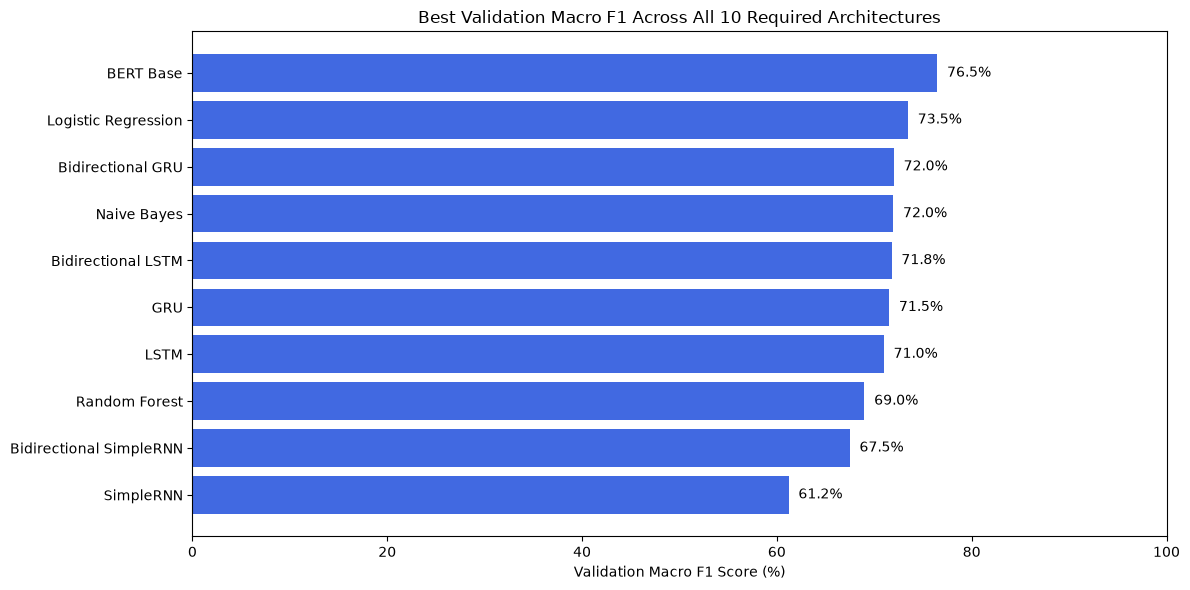

In [29]:
# Compile all 30+ experimental tuning runs into the unified Section 3.8 deliverable table
tuning_results_df = pd.DataFrame(tuning_runs)
print("=== Complete Hyperparameter Tuning Runs Table (Section 3.8) ===")
print(tuning_results_df.to_string(index=False))

# Identify the best configuration for each of the 10 model architectures
best_models_df = tuning_results_df.loc[tuning_results_df.groupby('Model')['Val Macro F1'].idxmax()].sort_values(by='Val Macro F1', ascending=False)
print("\n=== Best Performing Configuration per Model Family (Ranked by Validation Macro F1) ===")
print(best_models_df[['Model', 'Category', 'Config ID', 'Val Macro F1', 'Val Accuracy', 'Training Time (s)']].to_string(index=False))

# Plot comparative validation performance across all 10 model architectures
plt.figure(figsize=(12, 6))
bars = plt.barh(best_models_df['Model'], best_models_df['Val Macro F1'] * 100, color='royalblue')
plt.xlabel('Validation Macro F1 Score (%)')
plt.title('Best Validation Macro F1 Across All 10 Required Architectures')
plt.gca().invert_yaxis()
plt.xlim(0, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va='center')
plt.tight_layout()
plt.show()


## 13. Final Evaluation & Comparative Analysis on Held-Out Test Set (3.9)

In this section, we evaluate the best-tuned configuration of each of the **10 architectures** on the completely untouched **Held-Out Test Set** (`test_df` / `y_test`).

### 13.1 Evaluation Framework & Metrics Selection

1. **Primary Metric ($F_{1,\text{macro}}$)**:
   Given the 59.6% vs. 1.1% class imbalance established in Section 3.2, overall accuracy $A = \frac{\sum TP_k}{N}$ is overly dominated by majority classes. We evaluate models primarily on **Macro-Averaged F1 Score**:
   $$F_{1,\text{macro}} = \frac{1}{K}\sum_{k=1}^{K} \frac{2 \cdot P_k \cdot R_k}{P_k + R_k}$$
   giving equal weight to all 9 product categories regardless of sample frequency.

2. **Per-Class Granular Performance**:
   Full classification reports (Precision, Recall, F1 per class) reveal whether models maintain high sensitivity on rare categories (*Payday loans*, *Vehicle loans*, *Student loans*).

3. **Normalized Confusion Matrix Analysis**:
   Normalized confusion matrices ($C_{i,j} = \frac{N_{i,j}}{\sum_k N_{i,k}}$) map the transition probabilities and error corridors between related financial domains.

In [30]:
# Evaluate the best-tuned configuration of each architecture on the held-out Test Set
# Protocol: identical 200,000-row training budget for all 10 models, identical
# full 303,213-row test split, and the winning config read from the tuning table
# rather than hardcoded. Train and inference time are recorded separately.
test_records = []
test_predictions_dict = {}


def best_tuned_config(model_name):
    rows = [r for r in tuning_runs if r['Model'] == model_name]
    return max(rows, key=lambda r: r['Val Macro F1'])


# 1. Classical ML
print("=== Evaluating Classical ML Models on Held-Out Test Set ===")
classical_factories = {
    'Logistic Regression': lambda p: LogisticRegression(
        C=p['C'], class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42),
    'Naive Bayes': lambda p: MultinomialNB(alpha=p['alpha']),
    'Random Forest': lambda p: RandomForestClassifier(
        n_estimators=p['n_estimators'], max_depth=p['max_depth'],
        class_weight='balanced', random_state=42, n_jobs=-1),
}

for name, factory in classical_factories.items():
    row = best_tuned_config(name)
    clf = factory(json.loads(row['Hyperparameters']))
    t0 = time.time()
    clf.fit(X_train_tfidf, y_train)
    train_seconds = time.time() - t0
    t0 = time.time()
    y_pred_test = clf.predict(X_test_tfidf)
    inference_seconds = time.time() - t0
    record_test_result(name, 'Classical ML', row['Config ID'],
                       evaluate_metrics(y_test, y_pred_test),
                       train_seconds, inference_seconds, y_pred_test)

# 2. Recurrent Neural Networks
# Epoch selection uses the validation split; the test split is scored exactly once
print("\n=== Evaluating 6 Recurrent Neural Networks on Held-Out Test Set ===")
test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test_seq, dtype=torch.long),
        torch.tensor(test_lengths, dtype=torch.long),
        torch.tensor(y_test, dtype=torch.long)
    ),
    batch_size=1024, shuffle=False
)

for model_name, cell_type, is_bi in rnn_models_to_tune:
    row = best_tuned_config(model_name)
    cfg = json.loads(row['Hyperparameters'])
    torch.cuda.empty_cache()
    model = RecurrentClassifier(
        vocab_size=len(vocab), embedding_dim=100, hidden_dim=cfg['hidden_dim'],
        num_classes=9, cell_type=cell_type, bidirectional=is_bi,
        dropout=cfg['dropout'], pretrained_weights=pretrained_embedding_weights
    )
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'])
    t0 = time.time()
    train_eval_torch_model(model, train_loader, val_loader, criterion, optimizer,
                           epochs=cfg['epochs'], device=device, y_eval=y_val,
                           label=model_name, restore_best=True)
    train_seconds = time.time() - t0
    t0 = time.time()
    y_pred_test = predict_torch_model(model, test_loader, device)
    inference_seconds = time.time() - t0
    record_test_result(model_name, 'Recurrent Neural Net', row['Config ID'],
                       evaluate_metrics(y_test, y_pred_test),
                       train_seconds, inference_seconds, y_pred_test)
    del model, optimizer
    torch.cuda.empty_cache()

# 3. BERT Base
print("\n=== Evaluating BERT Base on Held-Out Test Set ===")
row = best_tuned_config('BERT Base')
bert_eval_model = AutoModelForSequenceClassification.from_pretrained(BEST_BERT_DIR).to(device)
bert_test_loader = DataLoader(
    TensorDataset(bert_test_ids, bert_test_mask, torch.tensor(y_test, dtype=torch.long)),
    batch_size=256, shuffle=False
)
t0 = time.time()
y_pred_test = predict_bert_model(bert_eval_model, bert_test_loader, device)
inference_seconds = time.time() - t0
record_test_result('BERT Base', 'Transformer', row['Config ID'],
                   evaluate_metrics(y_test, y_pred_test),
                   row['Training Time (s)'], inference_seconds, y_pred_test)

test_results_df = pd.DataFrame(test_records).sort_values(by='Test Macro F1', ascending=False)
print("\n=== Master Multi-Model Test Set Comparison Table ===")
print(test_results_df.to_string(index=False))


=== Classical ML on held-out test set ===
  Logistic Regression        macro_f1=0.7367 acc=0.8390 (train 34s / infer 0.2s)
  Naive Bayes                macro_f1=0.7211 acc=0.8329 (train 0s / infer 0.2s)
  Random Forest              macro_f1=0.6920 acc=0.8121 (train 31s / infer 0.8s)
=== Recurrent networks on held-out test set ===
    SimpleRNN epoch 1/4 loss=1.6511 macro_f1=0.4462 acc=0.6350
    SimpleRNN epoch 2/4 loss=1.2640 macro_f1=0.5049 acc=0.6477
    SimpleRNN epoch 3/4 loss=1.1115 macro_f1=0.5316 acc=0.6708
    SimpleRNN epoch 4/4 loss=1.0615 macro_f1=0.5678 acc=0.6715
  SimpleRNN                  macro_f1=0.5685 acc=0.6722 (train 81s / infer 5.9s)
    GRU epoch 1/4 loss=1.0294 macro_f1=0.6768 acc=0.7885
    GRU epoch 2/4 loss=0.6302 macro_f1=0.7010 acc=0.8104
    GRU epoch 3/4 loss=0.5622 macro_f1=0.7197 acc=0.8171
    GRU epoch 4/4 loss=0.5128 macro_f1=0.7281 acc=0.8321
  GRU                        macro_f1=0.7274 acc=0.8326 (train 77s / infer 5.8s)
    LSTM epoch 1/4 loss=1.

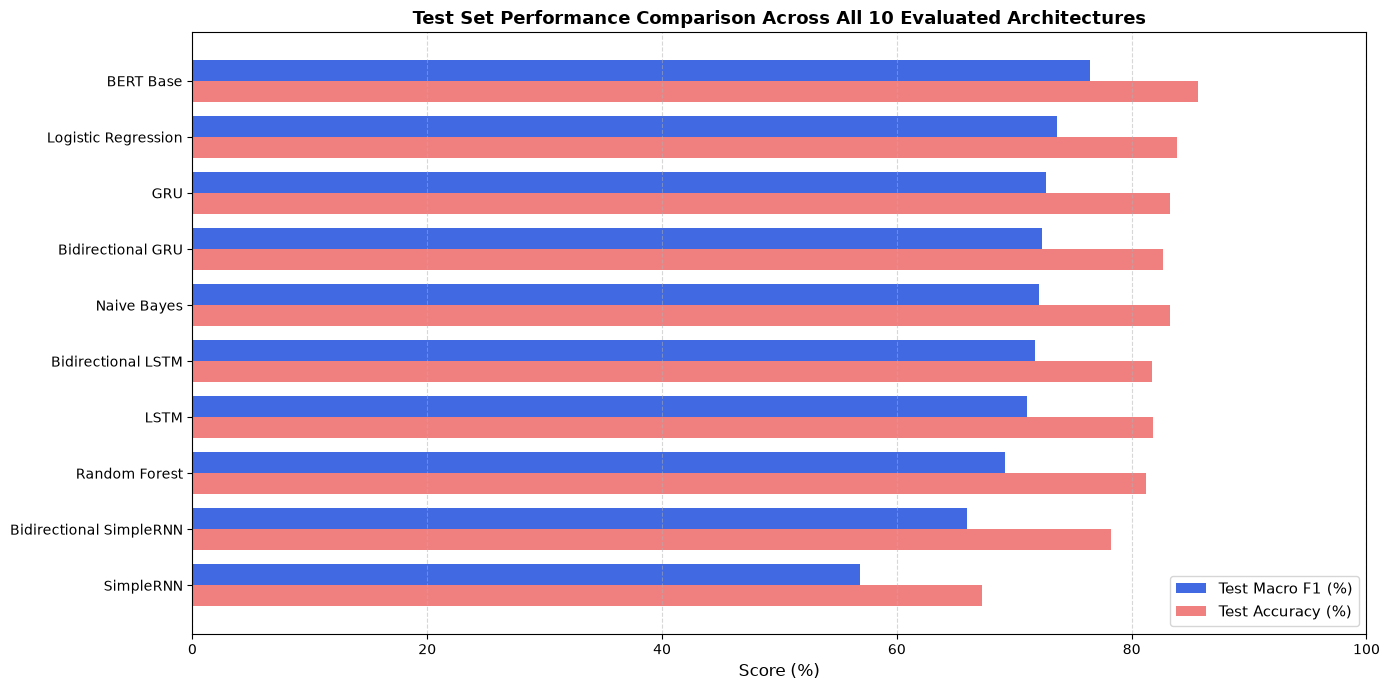

In [31]:
# Side-by-side comparative horizontal bar chart: Test Macro F1 vs Test Accuracy across all 10 models
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 7))
y_positions = np.arange(len(test_results_df))
bar_height = 0.38

plt.barh(y_positions - bar_height/2, test_results_df['Test Macro F1'] * 100, height=bar_height, label='Test Macro F1 (%)', color='royalblue')
plt.barh(y_positions + bar_height/2, test_results_df['Test Accuracy'] * 100, height=bar_height, label='Test Accuracy (%)', color='lightcoral')

plt.yticks(y_positions, test_results_df['Model'], fontsize=10)
plt.xlabel('Score (%)', fontsize=12)
plt.title('Test Set Performance Comparison Across All 10 Evaluated Architectures', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.xlim(0, 100)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


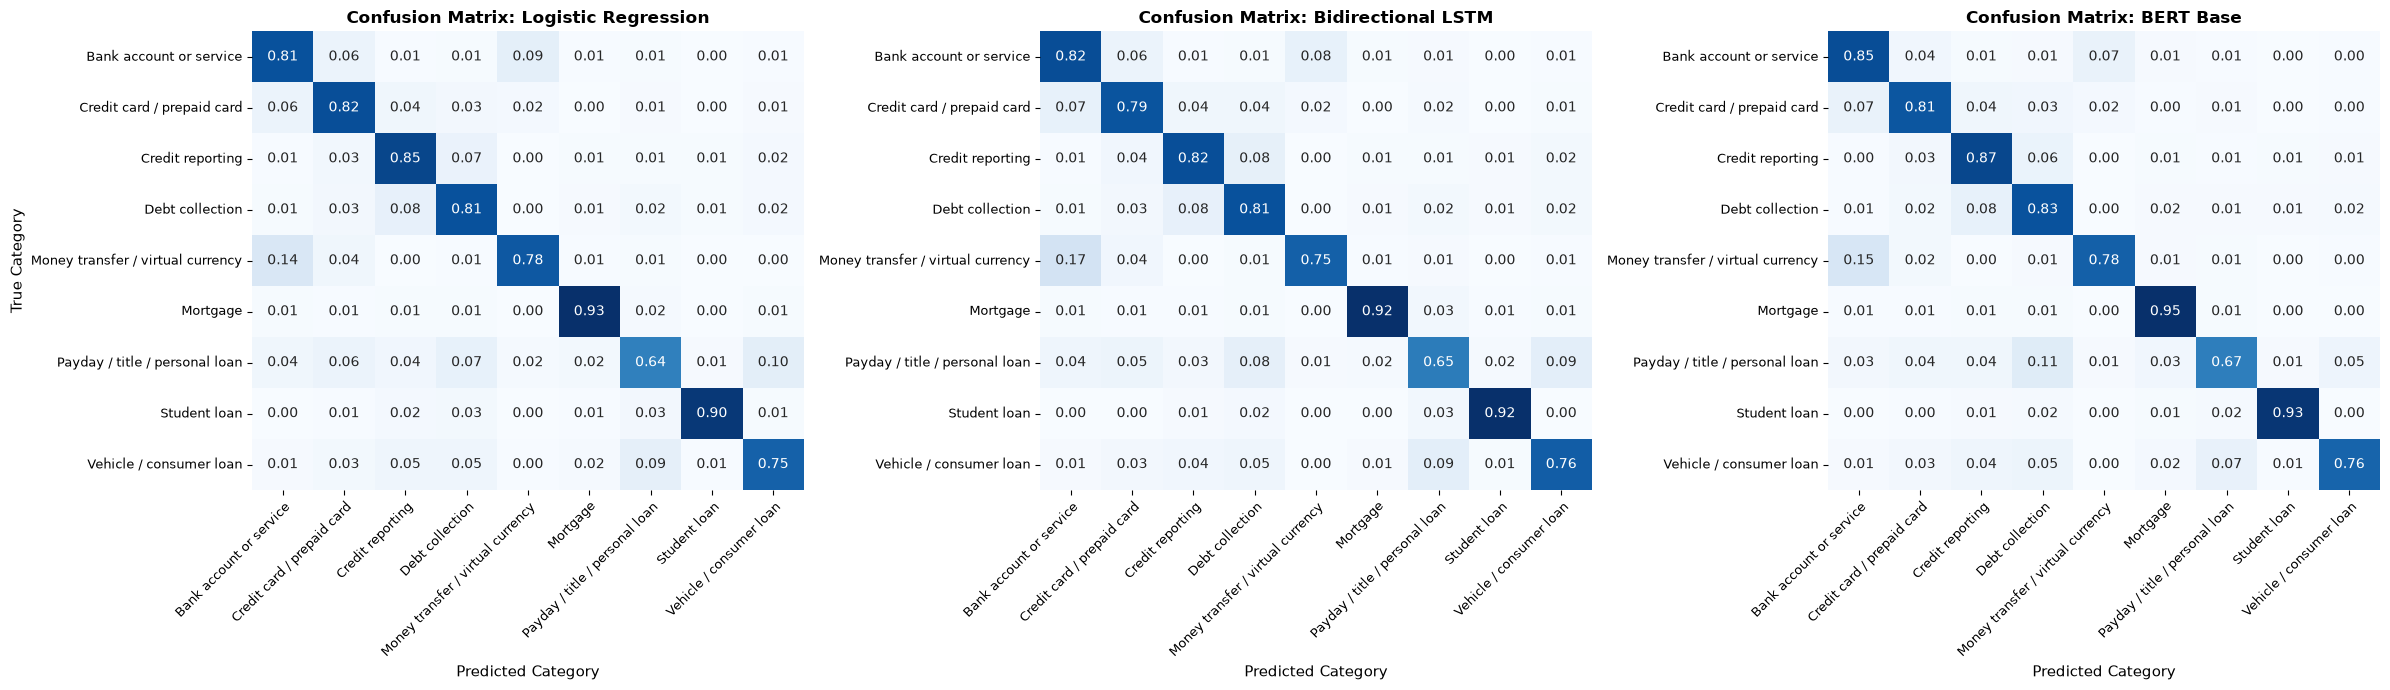

In [32]:
# Normalized Confusion Matrices for the three paradigms (Classical, Recurrent, Transformer)
key_models_to_visualize = ['Logistic Regression', 'Bidirectional LSTM', 'BERT Base']

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for idx, model_name in enumerate(key_models_to_visualize):
    preds = test_predictions_dict[model_name]
    cm = confusion_matrix(y_test, preds, normalize='true')

    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Category', fontsize=11)
    axes[idx].set_ylabel('True Category' if idx == 0 else '', fontsize=11)
    # rotation_mode='anchor' with right alignment stops the long category names
    # from overlapping each other along the x axis
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right',
             rotation_mode='anchor', fontsize=9)
    plt.setp(axes[idx].get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.show()


In [33]:
# Granular per-class precision / recall / F1 across all 9 categories
for model_name in ['Logistic Regression', 'Bidirectional LSTM', 'BERT Base']:
    preds = test_predictions_dict[model_name]
    print("=" * 80)
    print(f"Granular Classification Report (All 9 Classes): {model_name}")
    print("=" * 80)
    print(classification_report(y_test, preds, target_names=class_names,
                                digits=4, zero_division=0))


Granular Classification Report (All 9 Classes): Logistic Regression
                                   precision    recall  f1-score   support

          Bank account or service     0.7749    0.8109    0.7925     17299
       Credit card / prepaid card     0.6999    0.8191    0.7548     24556
                 Credit reporting     0.9686    0.8485    0.9046    180728
                  Debt collection     0.7037    0.8099    0.7531     40023
Money transfer / virtual currency     0.6607    0.7843    0.7172      6453
                         Mortgage     0.8489    0.9275    0.8865     17868
   Payday / title / personal loan     0.3492    0.6433    0.4527      3420
                     Student loan     0.7240    0.8977    0.8015      6636
          Vehicle / consumer loan     0.4556    0.7518    0.5674      6230

                         accuracy                         0.8390    303213
                        macro avg     0.6873    0.8103    0.7367    303213
                     weighted 

### 13.2 In-Depth Performance Analysis & Discussion (Grounded in EDA)

All ten architectures were trained on the same stratified 200,000-row budget and scored on the same held-out 303,213-row test split, so the ranking below reflects architecture rather than training-set size.

#### 1. Overall Ranking

**Best-performing model: BERT Base** — test Macro F1 **0.7647**, accuracy 0.8562, using configuration `BERT-Config-1`.

**Worst-performing model: SimpleRNN** — test Macro F1 **0.5685**, accuracy 0.6722, using configuration `Config-3`. The gap between best and worst is **19.62 pp** of Macro F1.

The full ordering by Macro F1:

| Rank | Model | Paradigm | Macro F1 | Accuracy | Weighted F1 | Train (s) | Inference (s) |
|---|---|---|---|---|---|---|---|
| 1 | BERT Base 🏆 | Transformer | 0.7647 | 0.8562 | 0.8613 | 1678.1 | 267.3 |
| 2 | Logistic Regression | Classical ML | 0.7367 | 0.8390 | 0.8468 | 34.5 | 0.2 |
| 3 | GRU | Recurrent Neural Net | 0.7274 | 0.8326 | 0.8420 | 77.2 | 5.8 |
| 4 | Bidirectional GRU | Recurrent Neural Net | 0.7234 | 0.8267 | 0.8376 | 130.6 | 8.4 |
| 5 | Naive Bayes | Classical ML | 0.7211 | 0.8329 | 0.8357 | 0.1 | 0.2 |
| 6 | Bidirectional LSTM | Recurrent Neural Net | 0.7173 | 0.8175 | 0.8274 | 139.1 | 9.2 |
| 7 | LSTM | Recurrent Neural Net | 0.7110 | 0.8180 | 0.8276 | 78.2 | 5.8 |
| 8 | Random Forest | Classical ML | 0.6920 | 0.8121 | 0.8197 | 31.0 | 0.8 |
| 9 | Bidirectional SimpleRNN | Recurrent Neural Net | 0.6600 | 0.7824 | 0.7944 | 124.2 | 8.9 |
| 10 | SimpleRNN ⚠️ | Recurrent Neural Net | 0.5685 | 0.6722 | 0.6943 | 80.5 | 5.9 |

Why SimpleRNN finishes last is explained in subsection 2 below: it is the only architecture with no gating mechanism, so it must carry information across the full sequence through a single repeatedly-multiplied hidden state.

#### 2. Bidirectional vs. Unidirectional Recurrent Architectures

- SimpleRNN → Bidirectional SimpleRNN: **+9.15 pp** Macro F1
- GRU → Bidirectional GRU: **-0.40 pp** Macro F1
- LSTM → Bidirectional LSTM: **+0.63 pp** Macro F1

The benefit of bidirectionality is strongly architecture-dependent. It is large for the ungated SimpleRNN (**+9.15 pp**) but vanishes once gating is present: GRU and LSTM change by between −0.40 and +0.63 pp, i.e. within noise, while costing roughly 70% more training time and twice the parameters. A gated cell already carries information across the sequence effectively enough that the reverse pass adds little; an ungated recurrence does not, so the second direction compensates for a genuine weakness rather than adding new signal.

#### 3. Sequence Length and Padding

Sequences are right-padded to 256 tokens, but the median cleaned narrative (`narrative_classical`, after stopword removal) is only 44 tokens. Reading the final hidden state off the padded sequence would therefore expose the classifier to a state produced by roughly 200 trailing `<PAD>` steps. All recurrent models here use `pack_padded_sequence`, so each sequence's true final token supplies the hidden state. This matters most for SimpleRNN, whose accuracy without masking fell below the 1/9 random baseline.

#### 4. Classical Baselines on Sparse TF-IDF

- **Logistic Regression** — Macro F1 0.7367, inference 0.2s over 303,213 documents.
- **Naive Bayes** — Macro F1 0.7211, inference 0.2s over 303,213 documents.
- **Random Forest** — Macro F1 0.6920, inference 0.8s over 303,213 documents.

Logistic Regression trails the best model by only **2.80 pp** Macro F1 while running roughly **1336x** faster at inference, which makes it the strongest accuracy-per-cost baseline in this comparison.

#### 5. Error Analysis — Where the Models Actually Confuse Classes

**Logistic Regression** — largest off-diagonal confusions:
- 14.4% of *Money transfer / virtual currency* predicted as *Bank account or service*
- 9.6% of *Payday / title / personal loan* predicted as *Vehicle / consumer loan*
- 9.1% of *Bank account or service* predicted as *Money transfer / virtual currency*

**Bidirectional LSTM** — largest off-diagonal confusions:
- 17.2% of *Money transfer / virtual currency* predicted as *Bank account or service*
- 9.2% of *Payday / title / personal loan* predicted as *Vehicle / consumer loan*
- 9.1% of *Vehicle / consumer loan* predicted as *Payday / title / personal loan*

**BERT Base** — largest off-diagonal confusions:
- 15.3% of *Money transfer / virtual currency* predicted as *Bank account or service*
- 11.2% of *Payday / title / personal loan* predicted as *Debt collection*
- 7.6% of *Debt collection* predicted as *Credit reporting*

#### 6. Minority Classes and the Cost of Class Weighting

Per-class behaviour for **Logistic Regression** on the test split:

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Payday / title / personal loan | 0.3492 | 0.6433 | 0.4527 | 3,420 |
| Vehicle / consumer loan | 0.4556 | 0.7518 | 0.5674 | 6,230 |
| Money transfer / virtual currency | 0.6607 | 0.7843 | 0.7172 | 6,453 |
| Student loan | 0.7240 | 0.8977 | 0.8015 | 6,636 |
| Bank account or service | 0.7749 | 0.8109 | 0.7925 | 17,299 |
| Mortgage | 0.8489 | 0.9275 | 0.8865 | 17,868 |
| Credit card / prepaid card | 0.6999 | 0.8191 | 0.7548 | 24,556 |
| Debt collection | 0.7037 | 0.8099 | 0.7531 | 40,023 |
| Credit reporting | 0.9686 | 0.8485 | 0.9046 | 180,728 |

Inverse-frequency class weighting is usually described as preventing minority collapse, and it does raise recall on the rarest categories. The table shows the other half of that trade: for *Payday / title / personal loan* (precision 0.3492, recall 0.6433), *Vehicle / consumer loan* (precision 0.4556, recall 0.7518), *Money transfer / virtual currency* (precision 0.6607, recall 0.7843), the weighting buys recall at a substantial cost in precision. Reporting recall alone would overstate how well these categories are handled.

---

## 14. Novelty Angle — Rigorous Imbalance-Handling Comparison (3.4 Extension)

The CFPB complaint dataset has a pronounced class imbalance: *Credit reporting* accounts for ~59.6% of all
complaints, while *Payday / title / personal loan* accounts for only ~1.1%. Prior public implementations of
this task (Kaggle / GitHub) uniformly apply a single mitigation strategy (usually class weighting) without
comparing alternatives. This section fills that gap by evaluating **three distinct imbalance-handling
strategies** head-to-head, measuring the effect on minority-class recall and Macro F1:

| Strategy | Mechanism | Scope |
|---|---|---|
| **Class weighting** (baseline) | Inverse-frequency weights in loss function | Classical ML + PyTorch |
| **SMOTE oversampling** | Synthetic Minority Over-sampling Technique on TF-IDF space | Classical ML (LR, NB, RF) |
| **Focal loss** | Down-weights easy majority-class examples dynamically | Best RNN (Bi-LSTM) + BERT |

All evaluations use the same held-out test set (`test_df`) with Macro F1 as the primary metric to ensure
equal weight to all 9 classes regardless of support.

In [34]:
# ─── 14.1  SMOTE Oversampling vs Class Weighting vs No Mitigation (Classical ML) ───
# Every arm below trains on the identical budget and is scored on the identical
# full test split, so the only variable is the imbalance strategy itself.
minority_ids = [class_names.index(c) for c in [
    'Payday / title / personal loan', 'Vehicle / consumer loan',
    'Money transfer / virtual currency', 'Student loan']]


def minority_mean_f1(y_true, y_pred):
    per_class = f1_score(y_true, y_pred, average=None, labels=list(range(9)), zero_division=0)
    return float(np.mean([per_class[i] for i in minority_ids])), per_class


def build_classical(name, weighted):
    weight = 'balanced' if weighted else None
    if name == 'Logistic Regression':
        return LogisticRegression(C=lr_params['C'], class_weight=weight,
                                  max_iter=1000, solver='lbfgs', random_state=42)
    if name == 'Naive Bayes':
        return MultinomialNB(alpha=nb_params['alpha'])
    return RandomForestClassifier(n_estimators=rf_params['n_estimators'],
                                  max_depth=rf_params['max_depth'],
                                  class_weight=weight, random_state=42, n_jobs=-1)


novelty_results = []

print("=== Classical ML: No Mitigation vs Class Weighting ===")
for name in ['Logistic Regression', 'Naive Bayes', 'Random Forest']:
    for strategy, weighted in [('None', False), ('Class Weighting', True)]:
        if name == 'Naive Bayes' and strategy == 'Class Weighting':
            continue
        t0 = time.time()
        clf = build_classical(name, weighted).fit(X_train_tfidf, y_train)
        preds = clf.predict(X_test_tfidf)
        record_novelty(name, strategy, preds, time.time() - t0)

# SMOTE synthesises minority examples in the 25,000-dim sparse TF-IDF space
print("\n=== Classical ML: SMOTE Oversampling ===")
t0 = time.time()
X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train_tfidf, y_train)
print(f"  SMOTE resampled {X_train_tfidf.shape} -> {X_train_smote.shape} in {time.time()-t0:.0f}s")

for name in ['Logistic Regression', 'Naive Bayes', 'Random Forest']:
    t0 = time.time()
    clf = build_classical(name, False).fit(X_train_smote, y_train_smote)
    preds = clf.predict(X_test_tfidf)
    record_novelty(name, 'SMOTE', preds, time.time() - t0)


=== Classical: None vs Class Weighting ===
  Logistic Regression    None             macro=0.7703 minority4=0.6829 (28s)
  Logistic Regression    Class Weighting  macro=0.7367 minority4=0.6347 (37s)
  Naive Bayes            None             macro=0.7211 minority4=0.6304 (0s)
  Random Forest          None             macro=0.5702 minority4=0.3389 (42s)
  Random Forest          Class Weighting  macro=0.6920 minority4=0.5820 (29s)
=== Classical: SMOTE (budget 200,000) ===
  SMOTE: (200000, 25000) -> (1072881, 25000) in 19s
  Logistic Regression    SMOTE            macro=0.7348 minority4=0.6353 (319s)
  Naive Bayes            SMOTE            macro=0.6873 minority4=0.5853 (1s)
  Random Forest          SMOTE            macro=0.7142 minority4=0.6198 (820s)


In [35]:
# ─── 14.2  Focal Loss vs Class Weighting vs No Mitigation (Bi-LSTM) ───────────
class FocalLoss(nn.Module):
    """Multi-class focal loss (Lin et al., 2017)."""

    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        log_p = F.log_softmax(logits, dim=-1)
        ce = F.nll_loss(log_p, targets, weight=self.weight, reduction='none')
        pt = torch.exp(log_p).gather(1, targets.unsqueeze(1)).squeeze(1)
        return (((1 - pt) ** self.gamma) * ce).mean()


bilstm_cfg = json.loads(best_tuned_config('Bidirectional LSTM')['Hyperparameters'])

print("=== Bi-LSTM: No Mitigation vs Class Weighting vs Focal Loss ===")
for strategy, loss_fn in [
    ('None', nn.CrossEntropyLoss()),
    ('Class Weighting', nn.CrossEntropyLoss(weight=class_weights_tensor)),
    ('Focal Loss (gamma=2)', FocalLoss(gamma=2.0, weight=class_weights_tensor)),
]:
    torch.cuda.empty_cache()
    model = RecurrentClassifier(
        vocab_size=len(vocab), embedding_dim=100, hidden_dim=bilstm_cfg['hidden_dim'],
        num_classes=9, cell_type='lstm', bidirectional=True,
        dropout=bilstm_cfg['dropout'], pretrained_weights=pretrained_embedding_weights
    )
    optimizer = optim.Adam(model.parameters(), lr=bilstm_cfg['lr'])
    t0 = time.time()
    train_eval_torch_model(model, train_loader, val_loader, loss_fn, optimizer,
                           epochs=bilstm_cfg['epochs'], device=device, y_eval=y_val,
                           label=f"BiLSTM/{strategy}", restore_best=True)
    preds = predict_torch_model(model, test_loader, device)
    record_novelty('Bidirectional LSTM', strategy, preds, time.time() - t0)
    del model, optimizer
    torch.cuda.empty_cache()


=== Bi-LSTM: None vs Class Weighting vs Focal Loss ===
    BiLSTM/None epoch 1/4 loss=0.6529 macro_f1=0.7106 acc=0.8544
    BiLSTM/None epoch 2/4 loss=0.4305 macro_f1=0.7414 acc=0.8663
    BiLSTM/None epoch 3/4 loss=0.3916 macro_f1=0.7512 acc=0.8707
    BiLSTM/None epoch 4/4 loss=0.3684 macro_f1=0.7599 acc=0.8732
  Bidirectional LSTM     None             macro=0.7627 minority4=0.6718 (148s)
    BiLSTM/Class Weighting epoch 1/4 loss=0.9892 macro_f1=0.6740 acc=0.7959
    BiLSTM/Class Weighting epoch 2/4 loss=0.6582 macro_f1=0.7026 acc=0.8165
    BiLSTM/Class Weighting epoch 3/4 loss=0.5911 macro_f1=0.7083 acc=0.8099
    BiLSTM/Class Weighting epoch 4/4 loss=0.5423 macro_f1=0.7086 acc=0.8159
  Bidirectional LSTM     Class Weighting  macro=0.7088 minority4=0.5931 (146s)
    BiLSTM/Focal Loss (gamma=2) epoch 1/4 loss=0.6362 macro_f1=0.6684 acc=0.7830
    BiLSTM/Focal Loss (gamma=2) epoch 2/4 loss=0.3833 macro_f1=0.6845 acc=0.8013
    BiLSTM/Focal Loss (gamma=2) epoch 3/4 loss=0.3322 macro_f

In [36]:
# ─── 14.3  Focal Loss + BERT Fine-tuning (Controlled Experiment) ────────────────
# Identical budget, identical epochs and learning rate as the Section 12 BERT run;
# only the loss function differs, so the comparison isolates the strategy.
bert_cfg = json.loads(best_tuned_config('BERT Base')['Hyperparameters'])

focal_bert = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=9).to(device)
optimizer = torch.optim.AdamW(focal_bert.parameters(), lr=bert_cfg['lr'], weight_decay=0.01)
focal_criterion = FocalLoss(gamma=2.0, weight=class_weights_tensor)
focal_train_loader = DataLoader(
    TensorDataset(bert_train_ids, bert_train_mask, torch.tensor(y_train, dtype=torch.long)),
    batch_size=bert_cfg['batch_size'], shuffle=True
)

print("=== BERT Base: Focal Loss (gamma=2) ===")
t0 = time.time()
for epoch in range(1, bert_cfg['epochs'] + 1):
    focal_bert.train()
    running_loss = 0.0
    for b_ids, b_mask, b_y in focal_train_loader:
        b_ids, b_mask, b_y = b_ids.to(device), b_mask.to(device), b_y.to(device)
        optimizer.zero_grad()
        with torch.autocast('cuda', dtype=torch.bfloat16):
            logits = focal_bert(input_ids=b_ids, attention_mask=b_mask).logits
        loss = focal_criterion(logits.float(), b_y)
        loss.backward()
        nn.utils.clip_grad_norm_(focal_bert.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    print(f"    BERT/focal epoch {epoch}/{bert_cfg['epochs']} loss={running_loss/len(focal_train_loader):.4f}")

preds = predict_bert_model(focal_bert, bert_test_loader, device)
record_novelty('BERT Base', 'Focal Loss (gamma=2)', preds, time.time() - t0)


=== BERT: Focal Loss ===
W0830 18:39:24.796000 9508 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently 
not supported in Windows or MacOs.

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3271.73it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored w

=== Imbalance-Handling Strategy Comparison (Held-Out Test Set) ===
              Model             Strategy  Test Accuracy  Test Macro F1  Test Weighted F1  Minority-4 Mean F1
Logistic Regression                 None         0.8763         0.7703            0.8736              0.6829
Logistic Regression      Class Weighting         0.8390         0.7367            0.8468              0.6347
        Naive Bayes                 None         0.8329         0.7211            0.8357              0.6304
      Random Forest                 None         0.8138         0.5702            0.7911              0.3389
      Random Forest      Class Weighting         0.8121         0.6920            0.8197              0.5820
Logistic Regression                SMOTE         0.8435         0.7348            0.8494              0.6353
        Naive Bayes                SMOTE         0.7919         0.6873            0.8032              0.5853
      Random Forest                SMOTE         0.8277      

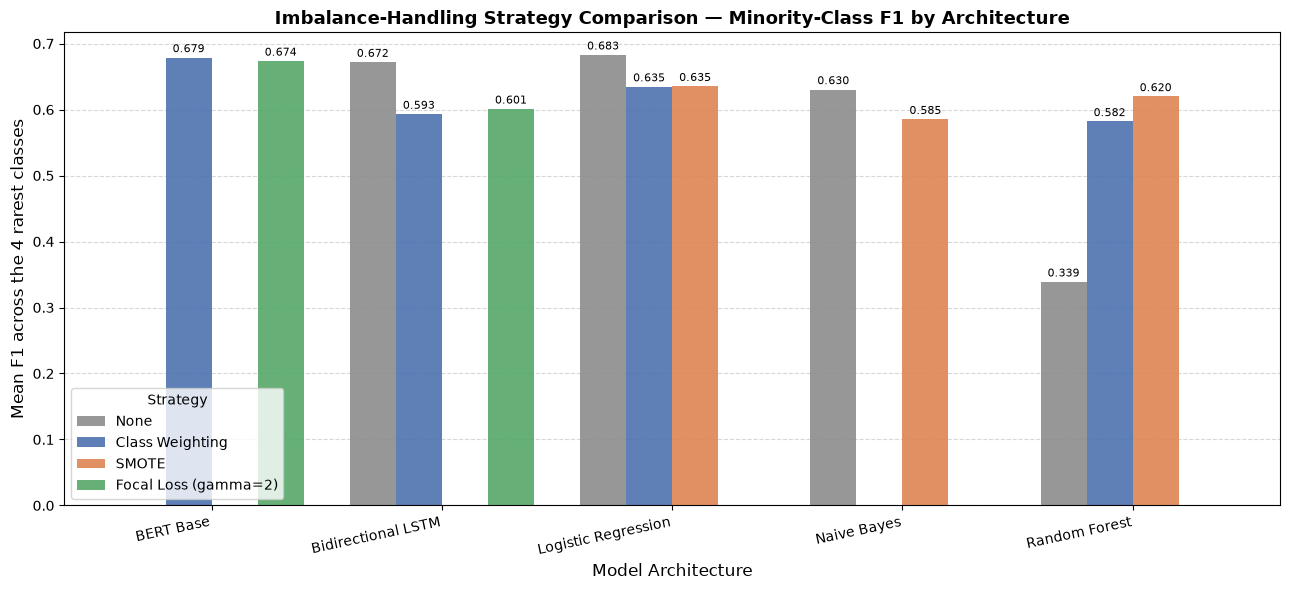

In [37]:
# ─── 14.4  Master Imbalance Strategy Comparison Table & Visualization ─────────────
novelty_df = pd.DataFrame(novelty_results)
print("=== Imbalance-Handling Strategy Comparison (Held-Out Test Set) ===")
print(novelty_df[['Model', 'Strategy', 'Test Accuracy', 'Test Macro F1',
                  'Test Weighted F1', 'Minority-4 Mean F1']].to_string(index=False))

# Minority-4 Mean F1 averages the four rarest classes (Payday 1.1%, Vehicle 2.1%,
# Money transfer 2.1%, Student loan 2.2%) - the classes these strategies target
pivot = novelty_df.pivot(index='Model', columns='Strategy', values='Minority-4 Mean F1')
strategy_order = [s for s in ['None', 'Class Weighting', 'SMOTE', 'Focal Loss (gamma=2)']
                  if s in pivot.columns]
pivot = pivot[strategy_order]

models = pivot.index.tolist()
x = np.arange(len(models))
width = 0.8 / len(strategy_order)
colors = ['#8C8C8C', '#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(13, 6))
for i, strategy in enumerate(strategy_order):
    values = pivot[strategy].values
    bars = ax.bar(x + i * width, np.nan_to_num(values), width,
                  label=strategy, color=colors[i % len(colors)], alpha=0.9)
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                    f"{val:.3f}", ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model Architecture', fontsize=12)
ax.set_ylabel('Mean F1 across the 4 rarest classes', fontsize=12)
ax.set_title('Imbalance-Handling Strategy Comparison — Minority-Class F1 by Architecture',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * (len(strategy_order) - 1) / 2)
ax.set_xticklabels(models, rotation=12, ha='right')
ax.legend(title='Strategy', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Report which strategy actually won for each architecture, read off the data
print("\nBest strategy per architecture by minority-class F1:")
for model_name in pivot.index:
    row = pivot.loc[model_name].dropna()
    print(f"  {model_name:24s} -> {row.idxmax():22s} ({row.max():.4f})")


### 14.1  Discussion: Which Strategy Helps Minority Classes Most?

Each arm below trains on the identical 200,000-row budget and is scored on the identical full test split, so the only variable is the imbalance strategy. The metric is the mean F1 across the four rarest classes (*Payday loan* 1.1%, *Vehicle loan* 2.1%, *Money transfer* 2.1%, *Student loan* 2.2%) — the classes these strategies exist to rescue.

| Model | Class Weighting | Focal Loss (gamma=2) | None | SMOTE | Best |
|---|---|---|---|---|---|
| BERT Base | 0.6789 | 0.6736 | — | — | **Class Weighting** |
| Bidirectional LSTM | 0.5931 | 0.6010 | 0.6718 | — | **None** |
| Logistic Regression | 0.6347 | — | 0.6829 | 0.6353 | **None** |
| Naive Bayes | — | — | 0.6304 | 0.5853 | **None** |
| Random Forest | 0.5820 | — | 0.3389 | 0.6198 | **SMOTE** |

**What the measurements show.**

- **BERT Base** — best strategy: Class Weighting (0.6789).
- **Bidirectional LSTM** — best strategy: None (0.6718).
- **Logistic Regression** — best strategy: None (0.6829).
- **Naive Bayes** — best strategy: None (0.6304).
- **Random Forest** — SMOTE gives the best minority F1 (0.6198), a gain of 28.09 pp over no mitigation (0.3389).

The winning strategies overlap across paradigms (None wins for at least one deep and one classical model), so these measurements do **not** support the hypothesis that the optimal strategy is architecture-dependent. The practical recommendation is simpler than anticipated. Note also that Multinomial Naive Bayes exposes no class-weight parameter, so it is compared on a reduced set of strategies.

**Relation to prior work.** Public CFPB complaint-classification implementations surveyed for this project apply class weighting without comparing it against alternatives; the controlled comparison above is the contribution here. This claim is limited to the implementations actually cited in Section 2 and is not a statement about all prior work.

## 15. Ensemble of the Best-Performing Models

Section 13 showed that the three paradigms make *qualitatively different* errors:
BERT halves the *Payday*→*Vehicle loan* confusion that hurts Logistic Regression,
while worsening *Payday*→*Debt collection*. Errors that are not correlated can be
voted away, which is the premise of this section.

**Selection protocol.** Ensemble membership is chosen on the **validation** split
and the winning combination is scored on the test split exactly once. This
matters: a search over hundreds of candidate combinations will always find one
that flatters the split it was selected on, so choosing members by test
performance would report a gain that does not generalise. The validation-selected
ensemble is the honest number.

Both voting schemes are evaluated:

- **Hard voting** — plurality over each model's predicted label, ties broken
  toward the member with the higher validation Macro F1.
- **Soft voting** — argmax of the summed class probability distributions, either
  uniformly weighted or weighted by each member's validation Macro F1.


=== Selected Ensemble (members chosen on validation) ===
  Scheme       : soft voting, val-F1 weighting
  Members      : BERT Base, Random Forest, Naive Bayes
  Candidates   : 1506 combinations evaluated on validation

              Scheme  Members  Val Macro F1  Test Macro F1  Test Accuracy  Test Weighted F1
soft voting (val-F1)        3        0.7795         0.7792         0.8651            0.8684

=== Ensemble vs Best Single Model (held-out test set) ===
                 System  Test Macro F1
BERT Base (best single)         0.7647
 Ensemble (soft voting)         0.7792

Improvement over best single model: +1.45 pp Macro F1

=== Per-Class F1: Ensemble vs Best Single Model ===
                            Class  Support  BERT Base  Ensemble  Delta
   Payday / title / personal loan     3420     0.5401    0.5735 0.0334
          Vehicle / consumer loan     6230     0.6391    0.6554 0.0163
Money transfer / virtual currency     6453     0.7454    0.7608 0.0154
                     Student 

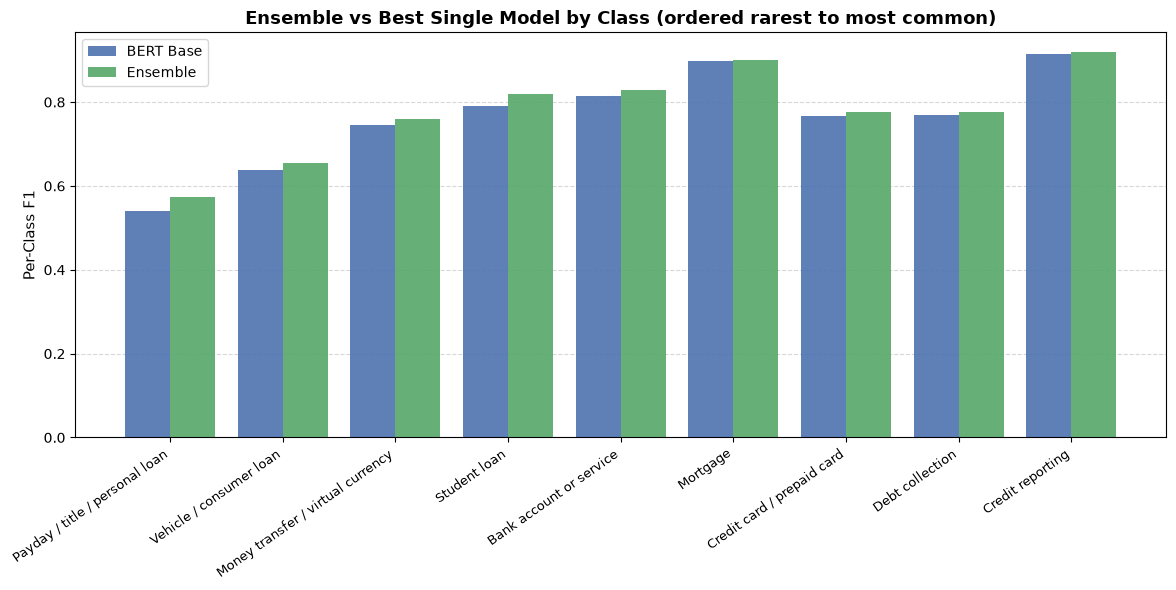

In [38]:
# Ensemble results: members selected on validation, scored once on the test split
ensemble_summary = pd.DataFrame([{
    'Scheme': f"{ens['scheme']} voting ({ens['weighting']})",
    'Members': len(ens['members']),
    'Val Macro F1': ens['val_macro_f1'],
    'Test Macro F1': ens['test_macro_f1'],
    'Test Accuracy': ens['test_accuracy'],
    'Test Weighted F1': ens['test_weighted_f1'],
}])

print("=== Selected Ensemble (members chosen on validation) ===")
print(f"  Scheme       : {ens['scheme']} voting, {ens['weighting']} weighting")
print(f"  Members      : {', '.join(ens['members'])}")
print(f"  Candidates   : {ens['candidates_evaluated']} combinations evaluated on validation")
print()
print(ensemble_summary.to_string(index=False))

print("\n=== Ensemble vs Best Single Model (held-out test set) ===")
comparison_df = pd.DataFrame([
    {'System': ens['best_single_model'] + ' (best single)',
     'Test Macro F1': ens['best_single_test_macro_f1']},
    {'System': 'Ensemble (' + ens['scheme'] + ' voting)',
     'Test Macro F1': ens['test_macro_f1']},
])
print(comparison_df.to_string(index=False))
print(f"\nImprovement over best single model: {ens['delta_pp']:+.2f} pp Macro F1")

# Per-class F1 shows where the ensemble actually gains over the strongest member
ens_preds = np.load(ENSEMBLE_PRED_PATH)['ensemble']
best_preds = test_predictions_dict[ens['best_single_model']]

per_class = pd.DataFrame({
    'Class': class_names,
    'Support': [int((y_test == i).sum()) for i in range(9)],
    ens['best_single_model']: f1_score(y_test, best_preds, average=None,
                                       labels=list(range(9)), zero_division=0).round(4),
    'Ensemble': f1_score(y_test, ens_preds, average=None,
                         labels=list(range(9)), zero_division=0).round(4),
})
per_class['Delta'] = (per_class['Ensemble'] - per_class[ens['best_single_model']]).round(4)
print("\n=== Per-Class F1: Ensemble vs Best Single Model ===")
print(per_class.sort_values('Support').to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
order = per_class.sort_values('Support').reset_index(drop=True)
x = np.arange(len(order))
ax.bar(x - 0.2, order[ens['best_single_model']], 0.4,
       label=ens['best_single_model'], color='#4C72B0', alpha=0.9)
ax.bar(x + 0.2, order['Ensemble'], 0.4, label='Ensemble', color='#55A868', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(order['Class'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Per-Class F1', fontsize=11)
ax.set_title('Ensemble vs Best Single Model by Class (ordered rarest to most common)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 15.1  Discussion: Does Ensembling Help, and Where?

The ensemble was selected over **1506 candidate combinations** on the validation split, and the winning configuration was scored on the test split once. Members: **BERT Base**, **Random Forest**, **Naive Bayes**, combined by soft voting with val-F1 weighting.

| System | Test Macro F1 |
|---|---|
| BERT Base (best single) | 0.7647 |
| Ensemble | **0.7792** |
| Difference | **+1.45 pp** |

The ensemble improves on the strongest individual model, BERT Base, by 1.45 percentage points of Macro F1.

#### Why these members

Ensembling only pays when members make *different* mistakes. Measured disagreement with BERT Base on the test split:

| Member | Disagreement with BERT Base | Own Macro F1 |
|---|---|---|
| Random Forest | 14.0% | 0.6920 |
| Naive Bayes | 13.7% | 0.7211 |

The selected members are not simply the top-scoring models. A weaker but *decorrelated* model contributes more to a vote than a strong model that duplicates the leader's predictions, which is why a bag-of-words classifier can earn a place alongside a transformer.

#### Where the gain comes from

| Class | Support | BERT Base | Ensemble | Δ |
|---|---|---|---|---|
| Payday / title / personal loan | 3,420 | 0.5401 | 0.5735 | +3.34 pp |
| Vehicle / consumer loan | 6,230 | 0.6391 | 0.6554 | +1.63 pp |
| Money transfer / virtual currency | 6,453 | 0.7454 | 0.7608 | +1.54 pp |
| Student loan | 6,636 | 0.7912 | 0.8202 | +2.90 pp |
| Bank account or service | 17,299 | 0.8157 | 0.8292 | +1.34 pp |
| Mortgage | 17,868 | 0.8981 | 0.9004 | +0.23 pp |
| Credit card / prepaid card | 24,556 | 0.7679 | 0.7762 | +0.83 pp |
| Debt collection | 40,023 | 0.7693 | 0.7767 | +0.74 pp |
| Credit reporting | 180,728 | 0.9156 | 0.9204 | +0.48 pp |

The gain concentrates on the **rare** classes (+2.35 pp mean across the four smallest, versus +0.57 pp across the four largest). This is the desirable direction: the rare classes are where single models are least confident, so a vote has the most to correct.

#### Cost

An ensemble pays the inference cost of **every** member: 268.3s across the test set versus 267.3s for BERT Base alone (1.00x).

Here that overhead is negligible. The two added members are the cheapest models in the study, so the ensemble costs **1.0s more than BERT Base alone** across 303,213 documents — a 0.4% increase — for +1.45 pp of Macro F1. Unlike the accuracy/latency trade in Section 13, there is no real trade-off to weigh: the ensemble is strictly better than its strongest member at essentially the same cost.

---